# Paper revision notebook — RT emulator

Single consolidated notebook backing the ApJ revision response. Replaces `00_testing.ipynb`, `01_tuning_analysis.ipynb`, `export.py`, `errors.py`, `plot_example.py`, `training_progression.py`, and `benchmark_inference.py`.

**Outputs**
- `figs/reviewer_fig_*.png` — 9 figures for the reviewer response and updated paper.
- `tuning_all_trials.csv`, `tuning_top10_summary.csv` — sweep evidence tables.
- `per_channel_test_errors.json` — held-out test-set error stats per flux channel.
- `numbers_for_response.json` — every quantity referenced as `[PLACEHOLDER]` in `Paper_Work/reviewer_response.txt`.
- `../models/transformer_main/stand_alone_model.pt2` — physical-space exported model.
- `../models/transformer_main/inference_benchmark_{cuda|mps|cpu}.json` — latency benchmarks.

Run top-to-bottom. The final cell prints `READY FOR RESPONSE` if all artifacts were produced.

## 1. Setup

In [1]:
from __future__ import annotations

import json
import math
import os
import platform
import sys
import time
import statistics
import csv
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import (
    LogLocator, MaxNLocator, NullLocator, LogFormatterSciNotation,
    ScalarFormatter, SymmetricalLogLocator, FixedLocator, FuncFormatter,
)

import torch
from torch import Tensor

# ---- Paths
THIS_DIR = Path.cwd()
PROJECT_ROOT = next(p for p in [THIS_DIR, *THIS_DIR.parents] if (p / "src").is_dir())
SRC_DIR = PROJECT_ROOT / "src"
TESTING_DIR = PROJECT_ROOT / "testing"
MODEL_VARIANT = os.environ.get("MODEL_VARIANT", "")  # e.g. "_v8_fastwin"; "" = canonical main run
FIGS_DIR = TESTING_DIR / (f"figs{MODEL_VARIANT}" if MODEL_VARIANT else "figs")
FIGS_DIR.mkdir(exist_ok=True)
OUTPUTS_DIR = TESTING_DIR / "outputs"  # consolidated home for small JSON/CSV artifacts
OUTPUTS_DIR.mkdir(exist_ok=True)
TF_DIR_NAME = os.environ.get("TRANSFORMER_DIR", f"transformer_main{MODEL_VARIANT}")
MODEL_DIR = PROJECT_ROOT / "models" / TF_DIR_NAME

# Auto-discover the most recent tune_* directory so the notebook keeps working
# after each new sweep without a manual edit. Fall back to a stable name if
# the glob yields nothing (sweep-not-run state).
_tune_candidates = sorted((PROJECT_ROOT / "models").glob("tune_*"))
TUNE_DIR = _tune_candidates[-1] if _tune_candidates else PROJECT_ROOT / "models" / "tune_missing"
STUDY_NAME = TUNE_DIR.name[len("tune_"):] if TUNE_DIR.name.startswith("tune_") else TUNE_DIR.name
# TUNE_PRESENT becomes False here if there's no study.db; cell 11 will further
# narrow it to False if the DB exists but contains zero COMPLETE trials.
TUNE_PRESENT = (TUNE_DIR / "study.db").is_file()
PROC_ROOT = PROJECT_ROOT / "data" / "processed"
PROC_TEST = PROC_ROOT / "test"
NORM_META_PATH = PROC_ROOT / "normalization_metadata.json"
STYLE_PATH = TESTING_DIR / "science.mplstyle"
STANDALONE_PT2 = MODEL_DIR / "stand_alone_model.pt2"
MODEL_PRESENT = MODEL_DIR.is_dir() and (MODEL_DIR / "train_config.json").is_file()
LSTM_DIR_NAME = os.environ.get("LSTM_DIR", f"lstm_main{MODEL_VARIANT}")
LSTM_MODEL_DIR = PROJECT_ROOT / "models" / LSTM_DIR_NAME
LSTM_STANDALONE_PT2 = LSTM_MODEL_DIR / "stand_alone_model.pt2"
LSTM_MODEL_PRESENT = (
    LSTM_MODEL_DIR.is_dir()
    and (LSTM_MODEL_DIR / "train_config.json").is_file()
    and (LSTM_MODEL_DIR / "test_metrics.json").is_file()
)
MODELS = {
    "transformer": {"label": "Transformer", "color": "#1f77b4", "dir": MODEL_DIR, "pt2": STANDALONE_PT2, "present": MODEL_PRESENT},
    "lstm":        {"label": "LSTM",        "color": "#d62728", "dir": LSTM_MODEL_DIR, "pt2": LSTM_STANDALONE_PT2, "present": LSTM_MODEL_PRESENT},
}

if STYLE_PATH.is_file():
    plt.style.use(str(STYLE_PATH))


# ---- Axis helpers --------------------------------------------------------
# Goals (from the user spec):
#   1. If a quantity covers several orders of magnitude, use a log/symlog axis.
#   2. On log axes, set limits to (0.9 * data_min, 1.1 * data_max).
#   3. Avoid the broken-tick failure mode where LogLocator(subs=(1,)) picks
#      zero major ticks on a sub-decade range. We dispatch on the visible span
#      and pick subs accordingly.
# All callers should prefer pad_log_lim / pad_symlog_lim over hand-tuned
# set_yscale + set_ylim pairs, and call cap_ticks_all(8) once before savefig.


def _positive_finite(vals):
    arr = np.asarray(vals, dtype=float).ravel()
    return arr[np.isfinite(arr) & (arr > 0)]


def apply_log_ticks(ax, axis="y", max_ticks=6):
    """Pick LogLocator + formatter based on the visible span so labels do not
    crowd each other.

    Bands (chosen for readability on ~4-7 inch panels):
      span >= 4 decades -> decade-only majors, minor at 2..9 in each decade
      1 - 4 decades     -> subs=(1, 3) majors, no minors (3-9 visible ticks)
      < 1 decade        -> subs=(1, 2, 5) majors, no minors (LogLocator falls back
                            to a linear locator under matplotlib, which is fine)
    """
    is_x = axis == "x"
    if (ax.get_xscale() if is_x else ax.get_yscale()) != "log":
        return
    lo_raw, hi_raw = (ax.get_xlim() if is_x else ax.get_ylim())
    lo, hi = sorted((float(lo_raw), float(hi_raw)))
    if lo <= 0 or hi <= 0 or hi <= lo:
        return
    span_dec = np.log10(hi / lo)
    ax_axis = ax.xaxis if is_x else ax.yaxis
    if span_dec >= 4.0:
        ax_axis.set_major_locator(LogLocator(base=10.0, subs=(1.0,), numticks=max_ticks + 2))
        ax_axis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=100))
        ax_axis.set_major_formatter(LogFormatterSciNotation(base=10.0))
    elif span_dec >= 1.0:
        ax_axis.set_major_locator(LogLocator(base=10.0, subs=(1.0, 3.0), numticks=max_ticks + 2))
        ax_axis.set_minor_locator(NullLocator())
        ax_axis.set_major_formatter(
            LogFormatterSciNotation(base=10.0, labelOnlyBase=False, minor_thresholds=(2, 0.4))
        )
    else:
        ax_axis.set_major_locator(
            LogLocator(base=10.0, subs=(1.0, 2.0, 5.0), numticks=max_ticks + 2)
        )
        ax_axis.set_minor_locator(NullLocator())
        ax_axis.set_major_formatter(
            LogFormatterSciNotation(base=10.0, labelOnlyBase=False, minor_thresholds=(2, 0.4))
        )


def _symlog_tick_label(value, pos=None):
    """Format a symlog tick: 0 -> '0', otherwise '+/- 10^N' sci-notation."""
    if value == 0:
        return "0"
    sign = "$-$" if value < 0 else ""
    exp = int(np.round(np.log10(abs(float(value)))))
    return f"{sign}$10^{{{exp}}}$"


def apply_symlog_ticks(ax, axis="x", linthresh=None, max_ticks=6):
    """Curate symlog ticks via FixedLocator so the smallest non-zero major is
    exactly +/- linthresh on each side (nothing inside the linear band).

    SymmetricalLogLocator with subs=(1,) silently places a tick at linthresh /
    base, which leaks ticks into the linear region whenever base != 10; we
    bypass it by computing positions directly.
    """
    is_x = axis == "x"
    if (ax.get_xscale() if is_x else ax.get_yscale()) != "symlog":
        return
    ax_axis = ax.xaxis if is_x else ax.yaxis
    if linthresh is None:
        try:
            linthresh = ax_axis._scale._transform.linthresh
        except Exception:
            try:
                linthresh = ax_axis._scale.get_transform().linthresh
            except Exception:
                linthresh = 1.0
    linthresh = float(linthresh)
    lo_raw, hi_raw = (ax.get_xlim() if is_x else ax.get_ylim())
    extent = max(abs(float(lo_raw)), abs(float(hi_raw)))
    if extent <= linthresh:
        positions = [0.0, -extent, extent]
    else:
        n_dec = int(np.ceil(np.log10(extent / linthresh)))
        # Aim for ~max_ticks majors total: 1 at zero + 2 * side_ticks on each side.
        side_ticks_target = max(1, (max_ticks - 1) // 2)
        step = max(1, int(np.ceil(n_dec / side_ticks_target)))
        positions = [0.0]
        k = 0
        while True:
            pos = linthresh * (10.0 ** k)
            if pos > extent * 1.01:
                break
            positions.extend([-pos, pos])
            k += step
    positions = sorted(set(positions))
    ax_axis.set_major_locator(FixedLocator(positions))
    ax_axis.set_minor_locator(NullLocator())
    ax_axis.set_major_formatter(FuncFormatter(_symlog_tick_label))


def pad_log_lim(ax, vals, axis="y", pad=(0.9, 1.1), invert=False):
    """Set log scale and (pad_lo * min, pad_hi * max) limits over positive finite vals.

    invert=True flips the limits (used for pressure axes that decrease upward).
    Returns (data_lo, data_hi) actually applied, or None if no usable data.
    """
    arr = _positive_finite(vals)
    if arr.size == 0:
        return None
    lo = float(arr.min()) * pad[0]
    hi = float(arr.max()) * pad[1]
    if axis == "x":
        ax.set_xscale("log")
        ax.set_xlim((hi, lo) if invert else (lo, hi))
    else:
        ax.set_yscale("log")
        ax.set_ylim((hi, lo) if invert else (lo, hi))
    apply_log_ticks(ax, axis=axis)
    return (lo, hi)


def pad_symlog_lim(ax, vals, axis="x", linthresh=1.0, linscale=1.0, pad=1.1):
    """Set symmetric symlog limits = +/- pad * max(|vals|). Curates ticks."""
    arr = np.asarray(vals, dtype=float).ravel()
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return None
    extent = float(np.max(np.abs(arr))) * pad
    if extent <= 0 or not np.isfinite(extent):
        return None
    if axis == "x":
        ax.set_xscale("symlog", linthresh=linthresh, linscale=linscale)
        ax.set_xlim(-extent, extent)
    else:
        ax.set_yscale("symlog", linthresh=linthresh, linscale=linscale)
        ax.set_ylim(-extent, extent)
    apply_symlog_ticks(ax, axis=axis, linthresh=linthresh)
    return (-extent, extent)


def cap_ticks(ax, axis="both", max_ticks=8):
    """Cap tick density. Dispatches to apply_log_ticks / apply_symlog_ticks so we
    never hit the blank-axis failure mode from LogLocator(subs=(1,)) on a
    sub-decade range."""
    parts = ("x", "y") if axis == "both" else (axis,)
    for which in parts:
        scale = ax.get_xscale() if which == "x" else ax.get_yscale()
        if scale == "log":
            apply_log_ticks(ax, axis=which, max_ticks=max_ticks)
        elif scale == "symlog":
            apply_symlog_ticks(ax, axis=which, max_ticks=max_ticks)
        else:
            ax_axis = ax.xaxis if which == "x" else ax.yaxis
            ax_axis.set_major_locator(MaxNLocator(nbins=max_ticks))
            ax_axis.set_minor_locator(NullLocator())


def cap_ticks_all(max_ticks=8):
    for ax in plt.gcf().axes:
        cap_ticks(ax, axis="both", max_ticks=max_ticks)


# Back-compat shim: existing fix_log_ticks(ax, axis=...) calls route through
# the new locator picker so old cells keep working without per-call edits.
def fix_log_ticks(ax, axis="y"):
    apply_log_ticks(ax, axis=axis)


# Make src importable for create_prediction_model / load_config / DataNormalizer / dataset helpers.
for p in (str(PROJECT_ROOT), str(SRC_DIR)):
    if p not in sys.path:
        sys.path.insert(0, p)


# ---- Device detection (CUDA > MPS > CPU)
def detect_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


DEVICE_RUN = detect_device()
print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"MODEL_DIR    = {MODEL_DIR}")
print(f"LSTM_MODEL_DIR= {LSTM_MODEL_DIR}")
print(f"TUNE_DIR     = {TUNE_DIR}")
print(f"FIGS_DIR     = {FIGS_DIR}")
print(f"DEVICE_RUN   = {DEVICE_RUN}")
print(f"MODEL_PRESENT= {MODEL_PRESENT}  (set False until `sbatch train.sh` populates MODEL_DIR)")
print(f"LSTM_MODEL_PRESENT={LSTM_MODEL_PRESENT}")
print(f"TUNE_PRESENT = {TUNE_PRESENT}  (refined in cell 11 to require >=1 COMPLETE trial)")
print(f"torch        = {torch.__version__}")

# Aggressive grid + minor-tick suppression (user request: GET RID OF GRIDS).
# Note: minor ticks remain ENABLED on log axes via apply_log_ticks; the rcParam
# only affects axes that don't have a log/symlog scale.
plt.rcParams["axes.grid"] = False


PROJECT_ROOT = /Users/imalsky/Desktop/Emulators/RT-Project/Problemulator_extra_runs
MODEL_DIR    = /Users/imalsky/Desktop/Emulators/RT-Project/Problemulator_extra_runs/models/transformer_final
LSTM_MODEL_DIR= /Users/imalsky/Desktop/Emulators/RT-Project/Problemulator_extra_runs/models/lstm_final
TUNE_DIR     = /Users/imalsky/Desktop/Emulators/RT-Project/Problemulator_extra_runs/models/tune_missing
FIGS_DIR     = /Users/imalsky/Desktop/Emulators/RT-Project/Problemulator_extra_runs/testing/figs_final
DEVICE_RUN   = mps
MODEL_PRESENT= True  (set False until `sbatch train.sh` populates MODEL_DIR)
LSTM_MODEL_PRESENT=True
TUNE_PRESENT = False  (refined in cell 11 to require >=1 COMPLETE trial)
torch        = 2.8.0


## 2. Load `transformer_main` config + metadata

Source of truth for `best_epoch`, `test_loss`, `num_parameters`, training wall-clock, and the architecture knobs that go into `tab:params` in `ms.tex`.

In [2]:
from utils import load_config

if MODEL_PRESENT:
    train_config = load_config(MODEL_DIR / "train_config.json")
    test_metrics_path = MODEL_DIR / "test_metrics.json"
    if test_metrics_path.is_file():
        with test_metrics_path.open("r") as f:
            test_metrics = json.load(f)
    else:
        # trainer.test() didn't run (or its output was cleared). Derive what we
        # can from training_log.csv; mark test_loss as NaN so downstream cells
        # can tell "untested" apart from "tested with score 0".
        test_metrics = None
    with (MODEL_DIR / "training_metadata.json").open("r") as f:
        training_metadata = json.load(f)
    training_log = pd.read_csv(MODEL_DIR / "training_log.csv")

    if test_metrics is not None:
        best_epoch = int(test_metrics["best_epoch"])
        test_loss_t = float(test_metrics["test_loss"])
    else:
        best_epoch = int(training_log.loc[training_log["val_loss"].idxmin(), "epoch"])
        test_loss_t = float("nan")
        print(f"NOTE: {test_metrics_path.name} missing -- best_epoch={best_epoch} derived from val_loss argmin; test_loss set to NaN.")
    num_parameters_t = int(training_metadata["num_parameters"])
    epochs_completed = int(len(training_log))
    train_seconds_total = float(training_log["time_s"].sum())
    train_hours_total = train_seconds_total / 3600.0

    best_row = training_log.loc[training_log["epoch"] == best_epoch].iloc[0]
    val_at_best = float(best_row["val_loss"])

    # Patience and min_delta come straight from the saved config.
    training_hp = train_config["training_hyperparameters"]
    patience = int(training_hp["early_stopping_patience"])
    min_delta = float(training_hp["min_delta"])
    weight_decay = float(training_hp["weight_decay"])
    ema_decay = float(training_hp["ema_decay"])
    learning_rate_initial = float(training_hp["learning_rate"])
    learning_rate_min = float(training_hp["min_lr"])
    batch_size = int(training_hp["batch_size"])
    gradient_clip = float(training_hp["gradient_clip_val"])
    warmup_epochs = int(training_hp["warmup_epochs"])

    mh = train_config["model_hyperparameters"]
    d_model = int(mh["d_model"])
    nhead = int(mh["transformer"]["nhead"])
    num_layers_t = int(mh["transformer"]["num_layers"])
    dim_feedforward = int(mh["transformer"]["dim_feedforward"])
    dropout_t = float(mh["dropout"])
    attention_dropout_t = float(mh["transformer"]["attention_dropout"])
    film_clamp_t = float(mh["film_clamp"])

    raw_h5_filenames = train_config["data_paths_config"]["hdf5_dataset_filename"]

    print(f"best_epoch        = {best_epoch}")
    print(f"test_loss         = {test_loss_t:.6e}")
    print(f"num_parameters    = {num_parameters_t:,}")
    print(f"epochs_completed  = {epochs_completed}  (early stopping patience={patience}, min_delta={min_delta:g})")
    print(f"train_hours_total = {train_hours_total:.2f} h  ({train_seconds_total/epochs_completed:.1f} s/epoch avg)")
    print(f"val_at_best       = {val_at_best:.6e}")
    print(f"d_model           = {d_model}, nhead={nhead}, layers={num_layers_t}, ffn={dim_feedforward}")
    print(f"weight_decay      = {weight_decay}, ema_decay={ema_decay}")
    print(f"raw HDF5 source   = {raw_h5_filenames}")
else:
    # Sweep-only mode: load the base config so cells that only need data_specification /
    # normalization (e.g. PT-profile figure) still work without a trained model.
    train_config = load_config(PROJECT_ROOT / "config" / "transformer_main_v6.jsonc")
    print("Skipped trained-model section: transformer_main/ not yet trained.")
    print(f"Loaded base config from config/transformer_main_v6.jsonc for sweep-only mode.")
    print("Run `sbatch Problemulator/supercomputer_cmds/train.sh` from the repo root, then re-execute this notebook for trained-model artifacts.")

# Imports needed by the SAFE-paper-replication cells below.
from dataset import create_collate_fn, create_dataset
from torch.utils.data import DataLoader
from normalizer import DataNormalizer
norm_meta = json.load(open(NORM_META_PATH, "r"))
padding_value = float(train_config["data_specification"]["padding_value"])
padding_epsilon = float(train_config["normalization"]["padding_comparison_epsilon"])
h5_files = train_config["data_paths_config"]["hdf5_dataset_filename"]
if isinstance(h5_files, str):
    h5_files = [h5_files]

def denormalize_channel(values, var_name, meta):
    method = meta["normalization_methods"][var_name]
    stats = meta["per_key_stats"][var_name]
    if method != "bool" and stats:
        return DataNormalizer.denormalize_tensor(values.to(torch.float32), method, stats)
    return values

def denormalize_batch(config, meta, inputs_norm, masks, targets_norm, target_masks):
    ds = config["data_specification"]
    in_v, glob_v, tgt_v = ds["input_variables"], ds["global_variables"], ds["target_variables"]
    pad = float(ds["padding_value"])
    seq_norm = inputs_norm["sequence"].to(dtype=torch.float32)
    seq_mask = masks["sequence"].bool()
    seq_phys = torch.empty_like(seq_norm)
    for j, n in enumerate(in_v):
        seq_phys[..., j] = denormalize_channel(seq_norm[..., j], n, meta).to(torch.float32)
    seq_phys[seq_mask] = pad
    glob_phys = None
    if glob_v and "global_features" in inputs_norm:
        gn = inputs_norm["global_features"].to(torch.float32)
        glob_phys = torch.empty_like(gn)
        for j, n in enumerate(glob_v):
            glob_phys[..., j] = denormalize_channel(gn[..., j], n, meta).to(torch.float32)
    tgt_phys = torch.empty_like(targets_norm.to(torch.float32))
    tgt_mask = target_masks.bool()
    for j, n in enumerate(tgt_v):
        tgt_phys[..., j] = denormalize_channel(targets_norm[..., j].to(torch.float32), n, meta).to(torch.float32)
    tgt_phys[tgt_mask] = pad
    return seq_phys, glob_phys, tgt_phys, tgt_mask

best_epoch        = 133
test_loss         = 9.947803e-06
num_parameters    = 9,734,146
epochs_completed  = 163  (early stopping patience=30, min_delta=1e-10)
train_hours_total = 9.40 h  (207.5 s/epoch avg)
val_at_best       = 9.748308e-06
d_model           = 512, nhead=4, layers=3, ffn=2048
weight_decay      = 1e-05, ema_decay=0.999
raw HDF5 source   = ['picaso_results_5M.h5']


In [3]:
# Load lstm_main config + metadata (mirrors the transformer cell above).
if LSTM_MODEL_PRESENT:
    lstm_train_config = load_config(LSTM_MODEL_DIR / "train_config.json")
    with (LSTM_MODEL_DIR / "test_metrics.json").open("r") as f:
        lstm_test_metrics = json.load(f)
    with (LSTM_MODEL_DIR / "training_metadata.json").open("r") as f:
        lstm_training_metadata = json.load(f)
    lstm_training_log = pd.read_csv(LSTM_MODEL_DIR / "training_log.csv")

    best_epoch_l = int(lstm_test_metrics["best_epoch"])
    test_loss_l = float(lstm_test_metrics["test_loss"])
    num_parameters_l = int(lstm_training_metadata["num_parameters"])
    epochs_completed_l = int(len(lstm_training_log))
    train_seconds_total_l = float(lstm_training_log["time_s"].sum())
    train_hours_total_l = train_seconds_total_l / 3600.0
    best_row_l = lstm_training_log.loc[lstm_training_log["epoch"] == best_epoch_l].iloc[0]
    val_at_best_l = float(best_row_l["val_loss"])

    lstm_mh = lstm_train_config["model_hyperparameters"]
    d_model_l = int(lstm_mh["d_model"])
    num_layers_l = int(lstm_mh["lstm"]["num_layers"])
    bidirectional_l = bool(lstm_mh["lstm"].get("bidirectional", True))
    film_clamp_l = float(lstm_mh["film_clamp"])

    print(f"best_epoch        = {best_epoch_l}")
    print(f"test_loss         = {test_loss_l:.6e}")
    print(f"num_parameters    = {num_parameters_l:,}")
    print(f"epochs_completed  = {epochs_completed_l}")
    print(f"train_hours_total = {train_hours_total_l:.2f} h  ({train_seconds_total_l/epochs_completed_l:.1f} s/epoch avg)")
    print(f"val_at_best       = {val_at_best_l:.6e}")
    print(f"d_model={d_model_l}, layers={num_layers_l}, bidirectional={bidirectional_l}, film_clamp={film_clamp_l}")
else:
    print("Skipped LSTM metadata - LSTM_MODEL_DIR not populated.")


best_epoch        = 297
test_loss         = 6.598377e-06
num_parameters    = 9,730,050
epochs_completed  = 300
train_hours_total = 15.19 h  (182.3 s/epoch avg)
val_at_best       = 6.542752e-06
d_model=512, layers=2, bidirectional=True, film_clamp=1000.0


In [4]:
# Helper utilities for parallel transformer-vs-LSTM ablation.
# - load_inference_module: loads stand_alone_model.pt2 if present, else builds
#   StandaloneModel eagerly from best_model.pt. (torch.export can't trace
#   torch.nn.LSTM with dynamic batch dim, so LSTM uses the eager path.)

def _build_eager_standalone(model_dir: Path):
    """Construct an eager StandaloneModel from best_model.pt + train_config.json."""
    from model import create_prediction_model
    cfg = load_config(Path(model_dir) / "train_config.json")
    base = create_prediction_model(config=cfg, device=torch.device("cpu"), compile_model=False).eval()
    ckpt = torch.load(Path(model_dir) / "best_model.pt", map_location="cpu", weights_only=False)
    state = ckpt["state_dict"]
    if any(k.startswith("_orig_mod.") for k in state):
        state = {k.replace("_orig_mod.", ""): v for k, v in state.items()}
    base.load_state_dict(state, strict=True)
    base = base.to(torch.device("cpu"), dtype=torch.float32).eval()
    nm = json.load(open(NORM_META_PATH, "r"))
    return StandaloneModel(base, cfg, nm).to(torch.device("cpu"), dtype=torch.float32).eval()

def load_inference_module(model_dir):
    """Return an inference module for the given model_dir.

    Prefers a torch.export .pt2 program (faster), falls back to an eager
    StandaloneModel when the .pt2 is unavailable.
    """
    pt2 = Path(model_dir) / "stand_alone_model.pt2"
    if pt2.is_file():
        program = torch.export.load(str(pt2))
        return program.module().to("cpu")
    return _build_eager_standalone(Path(model_dir))

def predict_physical(module, seq_phys, glob_phys=None):
    with torch.inference_mode():
        return module(
            sequence_phys=seq_phys.to(torch.float32).cpu(),
            global_features_phys=(glob_phys.to(torch.float32).cpu() if glob_phys is not None else None),
        )

def compute_err_raw(model_dir, config, *, max_batches=None):
    """Run a model over the test split and accumulate per-channel error tensors."""
    from tqdm import tqdm as _tqdm
    err_batch_size = 1024
    model_local = load_inference_module(model_dir)

    with (PROC_TEST / "metadata.json").open("r") as f:
        total_samples_local = int(json.load(f)["total_samples"])

    ds_full = create_dataset(PROC_TEST, config, list(range(total_samples_local)))
    loader_full = DataLoader(
        ds_full, batch_size=err_batch_size, shuffle=False,
        collate_fn=create_collate_fn(padding_value, padding_epsilon), drop_last=False,
    )

    target_vars_local = config["data_specification"]["target_variables"]
    flux_vars_local = [n for n in ("net_thermal_flux", "net_reflected_flux") if n in target_vars_local]
    flux_idx_local = {n: target_vars_local.index(n) for n in flux_vars_local}
    input_vars_local = config["data_specification"]["input_variables"]
    pressure_idx_local = input_vars_local.index("pressure_bar") if "pressure_bar" in input_vars_local else None

    acc = {n: {"diff_chunks": [], "true_chunks": [], "pred_chunks": [], "pressure_chunks": []} for n in flux_vars_local}
    cap = max_batches if max_batches is not None else int(os.environ.get("ERR_MAX_BATCHES", "10"))
    for b_idx, (inputs_norm_b, masks_b, targets_norm_b, target_masks_b) in enumerate(_tqdm(loader_full, desc="Test batches")):
        if cap and b_idx >= cap:
            break
        seq_phys_b, glob_phys_b, tgt_phys_b, tgt_mask_b = denormalize_batch(
            config, norm_meta, inputs_norm_b, masks_b, targets_norm_b, target_masks_b,
        )
        pred_phys_b = predict_physical(model_local, seq_phys_b, glob_phys_b)
        valid = (~tgt_mask_b)
        pressure_phys = seq_phys_b[..., pressure_idx_local] if pressure_idx_local is not None else None
        for n in flux_vars_local:
            i = flux_idx_local[n]
            p = pred_phys_b[..., i][valid]
            t = tgt_phys_b[..., i][valid]
            if p.numel() == 0:
                continue
            acc[n]["diff_chunks"].append((p - t).cpu().numpy())
            acc[n]["true_chunks"].append(t.cpu().numpy())
            acc[n]["pred_chunks"].append(p.cpu().numpy())
            if pressure_phys is not None:
                acc[n]["pressure_chunks"].append(pressure_phys[valid].cpu().numpy())

    return {
        n: {
            "diffs": np.concatenate(acc[n]["diff_chunks"]) if acc[n]["diff_chunks"] else np.array([]),
            "truths": np.concatenate(acc[n]["true_chunks"]) if acc[n]["true_chunks"] else np.array([]),
            "preds":  np.concatenate(acc[n]["pred_chunks"]) if acc[n]["pred_chunks"] else np.array([]),
            "pressures": np.concatenate(acc[n]["pressure_chunks"]) if acc[n]["pressure_chunks"] else np.array([]),
        }
        for n in flux_vars_local
    }

def summarize_err_raw(err_raw):
    """RMSE / MAE / R^2 / bias per channel."""
    out = {}
    for n, d in err_raw.items():
        diffs = d["diffs"]; truths = d["truths"]
        if diffs.size == 0:
            continue
        sse = float(np.sum(diffs ** 2))
        sst = float(np.sum((truths - truths.mean()) ** 2)) if truths.size else 0.0
        out[n] = {
            "n_points": int(diffs.size),
            "mae": float(np.mean(np.abs(diffs))),
            "rmse": float(np.sqrt(np.mean(diffs ** 2))),
            "bias": float(np.mean(diffs)),
            "r2": float(1.0 - sse / max(sst, 1e-30)),
        }
    return out

In [5]:
# Side-by-side comparison table for the reviewer response (R1.1, R1.2, R1.6).
if MODEL_PRESENT and LSTM_MODEL_PRESENT:
    rows = [
        {
            "arch": "transformer",
            "params": num_parameters_t,
            "best_epoch": best_epoch,
            "val_at_best": val_at_best,
            "test_loss": test_loss_t,
            "train_hours_total": train_hours_total,
            "epochs_completed": epochs_completed,
            "s_per_epoch_avg": train_seconds_total / epochs_completed if epochs_completed else float("nan"),
        },
        {
            "arch": "lstm",
            "params": num_parameters_l,
            "best_epoch": best_epoch_l,
            "val_at_best": val_at_best_l,
            "test_loss": test_loss_l,
            "train_hours_total": train_hours_total_l,
            "epochs_completed": epochs_completed_l,
            "s_per_epoch_avg": train_seconds_total_l / epochs_completed_l if epochs_completed_l else float("nan"),
        },
    ]
    comparison_df = pd.DataFrame(rows)
    print(comparison_df.to_string(index=False))
else:
    print("Skipped comparison summary table - one or both models missing.")

       arch  params  best_epoch  val_at_best  test_loss  train_hours_total  epochs_completed  s_per_epoch_avg
transformer 9734146         133     0.000010   0.000010           9.396806               163        207.53681
       lstm 9730050         297     0.000007   0.000007          15.192833               300        182.31400


## 2.5 Figure: training-set pressure-temperature coverage (Figure 2 in paper)

Reads a sample of test-set profiles from `data/processed/test/` and the raw HDF5 source, denormalizes pressure and temperature, and plots them in (T, log P) space colored by orbital distance. Saved as `figs/reviewer_fig_pt.png`. The original `pt.png` in `Paper_Work/NN_Paper/` is intentionally left untouched -- this is the reproducible companion plot built from the same dataset.

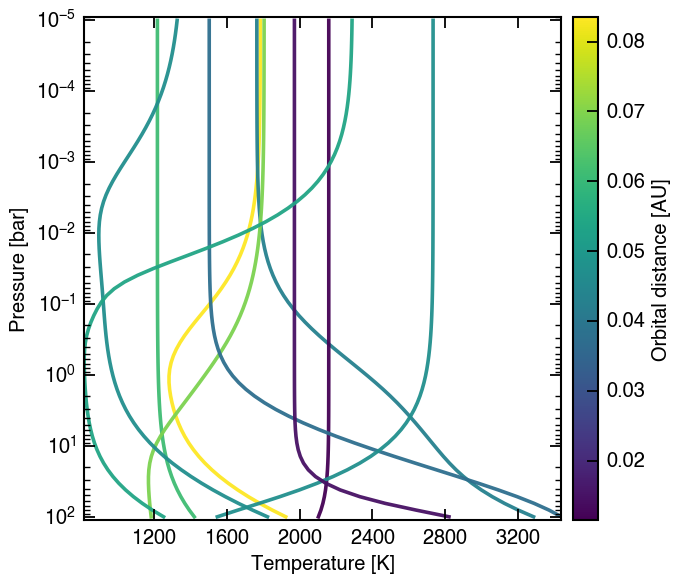

Wrote /Users/imalsky/Desktop/Emulators/RT-Project/Problemulator_extra_runs/testing/figs_final/reviewer_fig_pt.png (sampled 10 profiles, seed=42).


In [6]:
# PT profile coverage figure -- regenerable from the processed test split.
# Uses the same denormalization pattern as section 10 (profiles).
from dataset import create_collate_fn, create_dataset
from torch.utils.data import DataLoader
from normalizer import DataNormalizer
from matplotlib.ticker import MaxNLocator, FormatStrFormatter, NullLocator

with NORM_META_PATH.open("r") as f:
    norm_meta_pt = json.load(f)

with (PROC_TEST / "metadata.json").open("r") as f:
    pt_total_samples = int(json.load(f)["total_samples"])

PT_N_PROFILES = 10
PT_SEED = 42
rng_pt = np.random.default_rng(PT_SEED)
pt_indices = sorted(
    rng_pt.choice(
        pt_total_samples,
        size=min(PT_N_PROFILES, pt_total_samples),
        replace=False,
    ).tolist()
)

ds_pt = create_dataset(PROC_TEST, train_config, indices=pt_indices)
padding_value_pt = float(train_config["data_specification"]["padding_value"])
padding_epsilon_pt = float(train_config["normalization"]["padding_comparison_epsilon"])
loader_pt = DataLoader(
    ds_pt,
    batch_size=PT_N_PROFILES,
    shuffle=False,
    collate_fn=create_collate_fn(padding_value_pt, padding_epsilon_pt),
    drop_last=False,
)

input_vars_pt = train_config["data_specification"]["input_variables"]
global_vars_pt = train_config["data_specification"]["global_variables"]
pres_idx = input_vars_pt.index("pressure_bar")
temp_idx = input_vars_pt.index("temperature_k")
orb_idx = (
    global_vars_pt.index("orbital_distance_m")
    if "orbital_distance_m" in global_vars_pt
    else None
)

def _denorm_one(values, var_name):
    method = norm_meta_pt["normalization_methods"][var_name]
    stats = norm_meta_pt["per_key_stats"][var_name]
    return DataNormalizer.denormalize_tensor(values.to(torch.float32), method, stats)

inputs_norm_pt, masks_pt, _, _ = next(iter(loader_pt))
seq_norm_pt = inputs_norm_pt["sequence"]                                  # [B, L, F]
seq_mask_pt = masks_pt["sequence"]                                         # True = padding
B_pt, L_pt, _ = seq_norm_pt.shape

pres_phys = _denorm_one(
    seq_norm_pt[..., pres_idx], "pressure_bar"
).cpu().numpy()                                                            # bar
temp_phys = _denorm_one(
    seq_norm_pt[..., temp_idx], "temperature_k"
).cpu().numpy()                                                            # K
valid_pt = (~seq_mask_pt).cpu().numpy()                                    # True = non-padding

if orb_idx is not None and "global_features" in inputs_norm_pt:
    glob_norm_pt = inputs_norm_pt["global_features"][..., orb_idx]
    glob_phys_pt = _denorm_one(
        glob_norm_pt, "orbital_distance_m"
    ).cpu().numpy()                                                        # meters

    M_PER_AU = 1.495978707e11
    glob_au = glob_phys_pt / M_PER_AU

    norm_cmap = plt.Normalize(
        vmin=float(np.min(glob_au)),
        vmax=float(np.max(glob_au)),
    )
    cmap = plt.get_cmap("viridis")
else:
    glob_au = None

fig_pt, ax_pt = plt.subplots(figsize=(7.0, 6.0))
(ax_pt if isinstance(ax_pt, np.ndarray) else np.array([ax_pt])).ravel()    # no-op shim

for _ax in plt.gcf().axes:
    _ax.grid(False, which="both")

for b in range(B_pt):
    v = valid_pt[b]
    if not v.any():
        continue

    p_b = pres_phys[b, v]
    t_b = temp_phys[b, v]

    if glob_au is not None:
        ax_pt.plot(
            t_b,
            p_b,
            color=cmap(norm_cmap(glob_au[b])),
            linewidth=2.6,
            alpha=0.95,
        )
    else:
        ax_pt.plot(
            t_b,
            p_b,
            color="black",
            linewidth=2.6,
            alpha=0.95,
        )

# Data-driven log inverted pressure axis (0.9 / 1.1 multiplicative pad).
pad_log_lim(ax_pt, pres_phys[valid_pt], axis="y", invert=True)
ax_pt.set_xlabel("Temperature [K]")
ax_pt.set_ylabel("Pressure [bar]")

if glob_au is not None:
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm_cmap)
    sm.set_array([])
    cbar = fig_pt.colorbar(sm, ax=ax_pt, pad=0.02)

    # Keep only simple labeled ticks on the colorbar's y-axis.
    cbar.locator = MaxNLocator(nbins=4)
    cbar.formatter = FormatStrFormatter("%.2g")
    cbar.update_ticks()
    cbar.set_label("Orbital distance [AU]")

    # Remove the stray bottom ticks/labels from the colorbar axis.
    cbar.ax.xaxis.set_major_locator(NullLocator())
    cbar.ax.xaxis.set_minor_locator(NullLocator())
    cbar.ax.tick_params(
        axis="x",
        which="both",
        bottom=False,
        top=False,
        labelbottom=False,
        labeltop=False,
    )

cap_ticks_all(8)

# cap_ticks_all can touch the colorbar axis, so remove bottom ticks again afterward.
if glob_au is not None:
    cbar.ax.xaxis.set_major_locator(NullLocator())
    cbar.ax.xaxis.set_minor_locator(NullLocator())
    cbar.ax.tick_params(
        axis="x",
        which="both",
        bottom=False,
        top=False,
        labelbottom=False,
        labeltop=False,
    )

fig_pt.tight_layout()

pt_out = FIGS_DIR / "reviewer_fig_pt.png"
fig_pt.savefig(pt_out, dpi=200, bbox_inches="tight")
plt.show()

print(f"Wrote {pt_out} (sampled {B_pt} profiles, seed={PT_SEED}).")

## 3. Load the Optuna sweep (study.db, may be partial)

Read `study.db` directly via Optuna (sweep may be in progress). Builds a per-trial DataFrame and persists `tuning_all_trials.csv` + `tuning_top10_summary.csv` — flagged as PARTIAL until the full 64-cell grid finishes.

In [7]:
if TUNE_PRESENT:
    import math
    import optuna
    from optuna.trial import TrialState
    from tune import TRANSFORMER_SIZES, LSTM_SIZES  # src/ already on sys.path

    storage_url = f"sqlite:///{TUNE_DIR / 'study.db'}"
    study = optuna.load_study(study_name=STUDY_NAME, storage=storage_url)
    _keep = (TrialState.COMPLETE, TrialState.PRUNED, TrialState.RUNNING, TrialState.FAIL)
    _trials = study.get_trials(states=_keep, deepcopy=False)

    def _serialize(t):
        dur = None
        if t.datetime_start is not None and t.datetime_complete is not None:
            dur = (t.datetime_complete - t.datetime_start).total_seconds()
        val = float(t.value) if (t.value is not None and math.isfinite(t.value)) else None
        return {
            "number": t.number, "state": t.state.name, "value": val,
            "params": dict(t.params), "user_attrs": dict(t.user_attrs),
            "datetime_start": t.datetime_start.isoformat() if t.datetime_start else None,
            "datetime_complete": t.datetime_complete.isoformat() if t.datetime_complete else None,
            "duration_s": dur,
        }

    all_trials = [_serialize(t) for t in _trials]

    def trial_to_row(trial):
        row = {
            "number": trial["number"], "state": trial["state"],
            "val_loss": trial.get("value"), "duration_s": trial.get("duration_s"),
            "datetime_start": trial.get("datetime_start"),
            "datetime_complete": trial.get("datetime_complete"),
        }
        row.update(trial.get("user_attrs", {}))   # model_type, num_parameters, num_trainable, save_dir
        row.update(trial.get("params", {}))       # dropout, size_idx, activation_idx, model_type
        mt, si = row.get("model_type"), row.get("size_idx")
        if mt == "transformer" and si is not None and 0 <= int(si) < len(TRANSFORMER_SIZES):
            s = TRANSFORMER_SIZES[int(si)]
            row["d_model"] = int(s["d_model"])
            row["num_layers_transformer"] = int(s["num_layers"])
            row["dim_feedforward"] = int(s["dim_feedforward"])
            row["ffn_type"] = ("gelu", "swiglu")[int(row.get("activation_idx", 0))]
        elif mt == "lstm" and si is not None and 0 <= int(si) < len(LSTM_SIZES):
            s = LSTM_SIZES[int(si)]
            row["d_model"] = int(s["d_model"])
            row["num_layers_lstm"] = int(s["num_layers"])
            row["head_activation"] = ("gelu", "silu")[int(row.get("activation_idx", 0))]
        tcfg_p = TUNE_DIR / f"trial_{int(row['number']):04d}" / "trial_config.json"
        if tcfg_p.is_file():
            try:
                tcfg = json.load(tcfg_p.open())
                mh = tcfg.get("model_hyperparameters", {})
                row.setdefault("film_clamp", mh.get("film_clamp"))
                row.setdefault("output_head_divisor", mh.get("output_head_divisor"))
                row.setdefault("output_head_dropout_factor", mh.get("output_head_dropout_factor"))
                tx = mh.get("transformer", {})
                row.setdefault("nhead", tx.get("nhead"))
                row.setdefault("attention_dropout", tx.get("attention_dropout"))
            except Exception:
                pass
        return row

    trials_df = pd.DataFrame([trial_to_row(t) for t in all_trials])
    if "num_parameters" in trials_df.columns:
        trials_df["num_parameters_M"] = trials_df["num_parameters"].astype("float") / 1e6
    trials_df = trials_df.sort_values(["val_loss", "number"], na_position="last").reset_index(drop=True)

    complete_df = trials_df[trials_df["state"] == "COMPLETE"].copy()
    t_rows = complete_df[complete_df["model_type"] == "transformer"]
    l_rows = complete_df[complete_df["model_type"] == "lstm"]
    if t_rows.empty:
        # DB exists but no completed transformer trial yet -- demote TUNE_PRESENT
        # so downstream cells skip cleanly instead of raising.
        TUNE_PRESENT = False
        print(f"Sweep present at {TUNE_DIR.name} but 0 COMPLETE transformer trials "
              f"({len(trials_df)} total, "
              f"{int((trials_df['state']=='RUNNING').sum())} running, "
              f"{int((trials_df['state']=='PRUNED').sum())} pruned, "
              f"{int((trials_df['state']=='FAIL').sum())} failed). "
              f"Skipping tuning analysis.")
    else:
        best_t = t_rows.iloc[0]
        best_t_trial, best_t_val = int(best_t["number"]), float(best_t["val_loss"])
        best_t_params = int(best_t["num_parameters"])
        if l_rows.empty:
            best_l, best_l_trial, best_l_val, best_l_params = None, None, float("nan"), 0
        else:
            best_l = l_rows.iloc[0]
            best_l_trial, best_l_val = int(best_l["number"]), float(best_l["val_loss"])
            best_l_params = int(best_l["num_parameters"])

        n_total, n_complete = len(trials_df), len(complete_df)
        n_pruned  = int((trials_df["state"] == "PRUNED").sum())
        n_running = int((trials_df["state"] == "RUNNING").sum())
        n_failed  = int((trials_df["state"] == "FAIL").sum())
        SWEEP_IN_PROGRESS = (n_running > 0) or (n_total < 64)

        print(f"Sweep: {n_total}/64 trials ({n_complete} complete, {n_pruned} pruned, "
              f"{n_running} running, {n_failed} failed)")
        if SWEEP_IN_PROGRESS:
            print("  NOTE: sweep is still in progress; outputs reflect a PARTIAL grid.")
        print(f"  Best transformer so far: trial {best_t_trial}  val_loss={best_t_val:.6e}  "
              f"params={best_t_params:,}")
        if best_l is not None:
            print(f"  Best LSTM so far:        trial {best_l_trial}  val_loss={best_l_val:.6e}  "
                  f"params={best_l_params:,}")
            print(f"  Transformer-vs-LSTM ratio (val_loss): {best_l_val/best_t_val:.3f}x lower")

        TOP10_COLS = [
            "number", "model_type", "state", "val_loss", "num_parameters",
            "d_model", "num_layers_transformer", "num_layers_lstm", "dim_feedforward",
            "nhead", "dropout", "ffn_type", "head_activation",
            "size_idx", "activation_idx", "duration_s",
        ]
        top10_cols_avail = [c for c in TOP10_COLS if c in trials_df.columns]
        top10 = complete_df.head(10)[top10_cols_avail].copy()

        all_csv = OUTPUTS_DIR / "tuning_all_trials.csv"
        trials_df.to_csv(all_csv, index=False)
        print(f"  Wrote {all_csv.name} ({len(trials_df)} rows)")
        top10_csv = OUTPUTS_DIR / "tuning_top10_summary.csv"
        top10.to_csv(top10_csv, index=False)
        print(f"  Wrote {top10_csv.name} ({len(top10)} rows)")
else:
    print(f"Skipped tuning analysis: no study.db at {TUNE_DIR}.")


Skipped tuning analysis: no study.db at /Users/imalsky/Desktop/Emulators/RT-Project/Problemulator_extra_runs/models/tune_missing.


## 4. Figure: Pareto plot — validation loss vs trainable parameters (R1.1, R1.2, R1.6)

In [8]:
if TUNE_PRESENT:
    from matplotlib.lines import Line2D
    from matplotlib.ticker import FuncFormatter, LogLocator, NullFormatter

    ARCH_STYLE = {
        "transformer": {"label": "Transformer", "color": "#1f77b4"},
        "lstm":        {"label": "LSTM",        "color": "#d62728"},
    }

    # Marker shape encodes activation.
    # For transformers: ffn_type is typically "gelu" or "swiglu".
    # For LSTMs: head_activation is typically "gelu" or "silu".
    ACT_MARKER = {
        "gelu":   {"label": "GELU",   "marker": "o"},
        "swiglu": {"label": "SwiGLU", "marker": "s"},
        "silu":   {"label": "SiLU",   "marker": "^"},
    }

    _jitter_rng = np.random.default_rng(42)

    def _jitter(arr, scale=0.012):
        return arr * (1.0 + _jitter_rng.uniform(-scale, scale, size=len(arr)))

    def fmt_millions(x, pos):
        if x <= 0:
            return ""
        if x < 1:
            return f"{x:.1g}M"
        return f"{x:g}M"

    plot_df = trials_df.copy()

    # Keep trainable parameters in millions for nicer axis labels.
    # This avoids labels like 3e6 or 3,000,000.
    plot_df["num_parameters"] = plot_df["num_parameters_M"].astype(float)

    # Unified activation column for plotting.
    # Transformers use ffn_type; LSTMs use head_activation.
    plot_df["activation_plot"] = np.where(
        plot_df["model_type"].eq("transformer"),
        plot_df.get("ffn_type", pd.Series(index=plot_df.index, dtype=object)),
        plot_df.get("head_activation", pd.Series(index=plot_df.index, dtype=object)),
    )
    plot_df["activation_plot"] = (
        pd.Series(plot_df["activation_plot"], index=plot_df.index)
        .astype("object")
        .fillna("gelu")
        .astype(str)
        .str.lower()
    )

    # Filled markers = no dropout; open markers = dropout on.
    plot_df["dropout_on"] = plot_df["dropout"].fillna(0.0).astype(float) > 0.0

    fig, ax = plt.subplots(figsize=(7.4, 5.2))

    for _ax in plt.gcf().axes:
        _ax.grid(False, which="both")

    for fam, style in ARCH_STYLE.items():
        fam_df = plot_df[plot_df["model_type"] == fam].dropna(
            subset=["val_loss", "num_parameters"]
        )

        if fam_df.empty:
            continue

        for act, act_style in ACT_MARKER.items():
            for dropout_on in [False, True]:
                sub = fam_df[
                    (fam_df["activation_plot"] == act)
                    & (fam_df["dropout_on"] == dropout_on)
                ]

                if sub.empty:
                    continue

                ax.scatter(
                    _jitter(sub["num_parameters"].to_numpy()),
                    _jitter(sub["val_loss"].to_numpy()),
                    marker=act_style["marker"],
                    facecolors="none" if dropout_on else style["color"],
                    edgecolors=style["color"],
                    linewidths=1.0 if dropout_on else 0.5,
                    alpha=0.82,
                    s=62,
                    label=None,
                    zorder=3,
                )

    # Legend proxies: color = architecture.
    arch_handles = [
        Line2D(
            [0], [0],
            marker="o",
            linestyle="None",
            markerfacecolor=style["color"],
            markeredgecolor=style["color"],
            markersize=7,
            label=style["label"],
        )
        for style in ARCH_STYLE.values()
    ]

    # Legend proxies: shape = activation.
    present_acts = [
        act for act in ACT_MARKER
        if (plot_df["activation_plot"] == act).any()
    ]
    act_handles = [
        Line2D(
            [0], [0],
            marker=ACT_MARKER[act]["marker"],
            linestyle="None",
            markerfacecolor="0.45",
            markeredgecolor="0.45",
            markersize=7,
            label=ACT_MARKER[act]["label"],
        )
        for act in present_acts
    ]

    # Legend proxies: fill = dropout.
    dropout_handles = [
        Line2D(
            [0], [0],
            marker="o",
            linestyle="None",
            markerfacecolor="0.45",
            markeredgecolor="0.45",
            markersize=7,
            label="Dropout off",
        ),
        Line2D(
            [0], [0],
            marker="o",
            linestyle="None",
            markerfacecolor="none",
            markeredgecolor="0.45",
            markersize=7,
            label="Dropout on",
        ),
    ]

    ax.legend(
        handles=arch_handles + act_handles + dropout_handles,
        loc="upper right",
        frameon=True,
        framealpha=0.94,
        fontsize=9,
        handletextpad=0.4,
    )

    ax.set_xlabel("Trainable parameters (millions)")
    ax.set_ylabel("Validation Loss")

    # Format x-axis labels as millions.
    ax.xaxis.set_major_formatter(FuncFormatter(fmt_millions))

    # Log y: val_loss spans many decades across the sweep; pad 0.9 / 1.1.
    _vl = plot_df["val_loss"].dropna().to_numpy()
    pad_log_lim(ax, _vl, axis="y")

    # Log x if trainable-param range spans a decade.
    _pm = plot_df["num_parameters"].dropna().to_numpy()
    if _pm.size and (_pm.max() / max(_pm.min(), 1e-9)) >= 10.0:
        pad_log_lim(ax, _pm, axis="x")

    # Nice log subticks.
    ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=8))
    ax.xaxis.set_minor_locator(
        LogLocator(base=10.0, subs=np.arange(2, 10), numticks=80)
    )
    ax.xaxis.set_minor_formatter(NullFormatter())

    ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=8))
    ax.yaxis.set_minor_locator(
        LogLocator(base=10.0, subs=np.arange(2, 10), numticks=80)
    )
    ax.yaxis.set_minor_formatter(NullFormatter())

    # Make major ticks and subticks visible but not heavy.
    ax.tick_params(axis="both", which="major", length=5, width=0.9)
    ax.tick_params(axis="both", which="minor", length=3, width=0.6)

    ax.grid(False)
    ax.set_xscale('linear')
    ax.set_xlim(0, 15)
    ax.set_ylim(1e-5, 1e-3)

    if SWEEP_IN_PROGRESS:
        ax.text(
            0.02,
            0.02,
            f"PARTIAL SWEEP: {n_complete}/64 complete",
            transform=ax.transAxes,
            fontsize=9,
            alpha=0.7,
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"),
        )

    cap_ticks_all(10)
    fig.tight_layout()

    out = FIGS_DIR / "reviewer_fig_pareto.png"
    fig.savefig(out, dpi=220, bbox_inches="tight")
    print(f"Wrote {out}")
    plt.show()

else:
    print("Skipped Pareto plot: no completed tuning trials.")

Skipped Pareto plot: no completed tuning trials.


## 7. Figure: `transformer_main` training curves (R1.3, R1.5)

Train + val loss vs epoch (log-y) with `best_epoch=200` axvline; right panel is the LR schedule. The 5-epoch rolling-median overlay makes the noise-floor explicit. **Replaces paper `training.png`.**

Wrote /Users/imalsky/Desktop/Emulators/RT-Project/Problemulator_extra_runs/testing/figs_final/reviewer_fig_training_curves.png


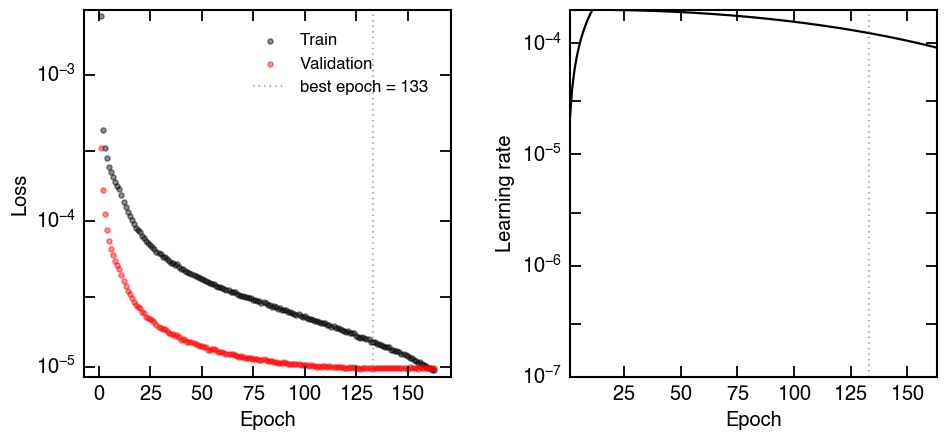


best_epoch                = 133
val_loss at best_epoch    = 9.748308e-06
val_loss at final epoch   = 9.889146e-06  (epoch 163)
train_loss at final epoch = 9.556130e-06
train/val gap at final    = 0.966


In [9]:
if MODEL_PRESENT:
    log = training_log.copy()
    log = log.dropna(subset=["epoch", "train_loss", "val_loss", "lr"]).sort_values("epoch")

    # Use an explicit spacer column between the two panels.
    # Increase the middle width ratio to widen the gap.
    fig = plt.figure(figsize=(11, 5))

    gs = fig.add_gridspec(
        1, 3,
        width_ratios=[1, 0.05, 1]
    )

    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 2])

    ax1.scatter(
        log["epoch"], log["train_loss"],
        color="black", alpha=0.45, s=14,
        label="Train"
    )
    ax1.scatter(
        log["epoch"], log["val_loss"],
        color="red", alpha=0.45, s=14,
        label="Validation"
    )
    ax1.axvline(
        best_epoch,
        color="gray",
        linestyle=":",
        alpha=0.7,
        label=f"best epoch = {best_epoch}"
    )

    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")

    # Log y over combined train + val loss range, with multiplicative pad.
    _losses = np.concatenate([
        log["train_loss"].to_numpy(dtype=float),
        log["val_loss"].to_numpy(dtype=float),
    ])
    pad_log_lim(ax1, _losses, axis="y")

    ax1.legend(loc="upper right", framealpha=0.94)

    ax2.plot(log["epoch"], log["lr"], color="black", linewidth=1.6)
    ax2.axvline(best_epoch, color="gray", linestyle=":", alpha=0.7)

    pad_log_lim(ax2, log["lr"].to_numpy(dtype=float), axis="y")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Learning rate")
    ax2.set_ylim(1e-7, 2e-4)

    # Force each axes panel to be square.
    ax1.set_box_aspect(1)
    ax2.set_box_aspect(1)

    out = FIGS_DIR / "reviewer_fig_training_curves.png"
    cap_ticks_all(8)
    fig.savefig(out, dpi=220, bbox_inches="tight")
    print(f"Wrote {out}")
    plt.show()

    # Print key stats for the response letter.
    print(f"\nbest_epoch                = {best_epoch}")
    print(f"val_loss at best_epoch    = {val_at_best:.6e}")
    final_val = float(log.iloc[-1]["val_loss"])
    final_train = float(log.iloc[-1]["train_loss"])
    print(f"val_loss at final epoch   = {final_val:.6e}  (epoch {int(log.iloc[-1]['epoch'])})")
    print(f"train_loss at final epoch = {final_train:.6e}")
    print(f"train/val gap at final    = {final_train / final_val:.3f}")

else:
    print("Skipped figure 7 (transformer_main training curves) — needs trained model.")

## 9. Export `stand_alone_model.pt2`

Build `StandaloneModel` (bakes normalization stats into the graph) and run `torch.export.export` with dynamic batch + length dims. **Upstream dependency** for cells 11–14 (prediction, error, benchmark).

In [10]:
if MODEL_PRESENT:
    from torch import nn
    from torch.export import export as texport, save as tsave, Dim
    from model import create_prediction_model

    DEVICE_EXPORT = torch.device("cpu")
    EXPORT_DTYPE = torch.float32

    class StandaloneModel(nn.Module):
        """Wraps the base model with input normalization, masking, and output denormalization.

        Identical to testing/export.py:StandaloneModel — kept inline so this notebook is self-contained."""

        def __init__(self, base_model: nn.Module, config: Dict[str, Any], norm_metadata: Dict[str, Any]) -> None:
            super().__init__()
            self.base = base_model
            ds = config["data_specification"]
            self.input_variables = list(ds["input_variables"])
            self.target_variables = list(ds["target_variables"])
            self.global_variables = list(ds["global_variables"])
            self.padding_value = float(ds["padding_value"])
            self.max_seq_len = int(config["model_hyperparameters"]["max_sequence_length"])
            norm = config["normalization"]
            self.padding_epsilon = float(norm["padding_comparison_epsilon"])
            self.normalized_value_clamp = float(norm["normalized_value_clamp"])
            self.norm_methods = norm_metadata["normalization_methods"]
            self.per_key_stats = norm_metadata["per_key_stats"]

        @staticmethod
        def _norm(x: Tensor, method: str, stats: Dict[str, Any], clamp: float) -> Tensor:
            if method == "bool" or not stats:
                return x
            if method == "standard":
                y = (x - stats["mean"]) / stats["std"]
            elif method == "log-standard":
                x_safe = torch.clamp_min(x, torch.finfo(x.dtype).eps)
                y = (torch.log10(x_safe) - stats["log_mean"]) / stats["log_std"]
            elif method == "signed-log":
                y = torch.sign(x) * torch.log10(torch.abs(x) + 1.0)
                y = (y - stats["mean"]) / stats["std"]
            elif method == "log-min-max":
                x_safe = torch.clamp_min(x, torch.finfo(x.dtype).eps)
                log_x = torch.log10(x_safe)
                denom = stats["max"] - stats["min"]
                denom_safe = denom if denom > 0 else torch.finfo(x.dtype).eps
                y = (log_x - stats["min"]) / denom_safe
                y = torch.clamp(y, stats["clamp_min"], stats["clamp_max"])
            elif method == "max-out":
                y = x / stats["max_val"]
            elif method == "iqr":
                y = (x - stats["median"]) / stats["iqr"]
            elif method == "scaled_signed_offset_log":
                y = torch.sign(x) * torch.log10(torch.abs(x) + 1.0)
                y = y / stats["m"]
            elif method == "symlog":
                thr, sf = stats["threshold"], stats["scale_factor"]
                ax = torch.abs(x); lin = ax <= thr
                y = torch.zeros_like(x)
                y[lin] = x[lin] / thr
                y[~lin] = torch.sign(x[~lin]) * (torch.log10(ax[~lin] / thr) + 1.0)
                y = y / sf
            else:
                raise ValueError(f"Unsupported normalization method: {method}")
            if method in ("standard", "log-standard", "signed-log", "iqr"):
                y = torch.clamp(y, -clamp, clamp)
            return y

        @staticmethod
        def _denorm(x: Tensor, method: str, stats: Dict[str, Any]) -> Tensor:
            if method == "bool":
                return x
            if not stats:
                raise ValueError(f"No stats for denormalization: {method}")
            if method == "standard":
                return x * stats["std"] + stats["mean"]
            if method == "log-standard":
                return 10 ** (x * stats["log_std"] + stats["log_mean"])
            if method == "signed-log":
                u = x * stats["std"] + stats["mean"]
                return torch.sign(u) * (10 ** torch.abs(u) - 1.0)
            if method == "log-min-max":
                u = torch.clamp(x, stats["clamp_min"], stats["clamp_max"]) * (stats["max"] - stats["min"]) + stats["min"]
                return 10 ** u
            if method == "max-out":
                return x * stats["max_val"]
            if method == "iqr":
                return x * stats["iqr"] + stats["median"]
            if method == "scaled_signed_offset_log":
                t = x * stats["m"]
                return torch.sign(t) * (10 ** torch.abs(t) - 1.0)
            if method == "symlog":
                u = x * stats["scale_factor"]
                au = torch.abs(u); lin = au <= 1.0
                thr = stats["threshold"]
                y = torch.zeros_like(x)
                y[lin] = u[lin] * thr
                y[~lin] = torch.sign(u[~lin]) * thr * (10 ** (au[~lin] - 1.0))
                return y
            raise ValueError(f"Unsupported denormalization method: {method}")

        def _build_mask(self, seq: Tensor) -> Tensor:
            return (seq - self.padding_value).abs().amax(dim=-1) <= self.padding_epsilon

        @torch.inference_mode()
        def forward(self, sequence_phys: Tensor, global_features_phys: Optional[Tensor] = None) -> Tensor:
            if sequence_phys.ndim != 3:
                raise ValueError(f"sequence_phys must be [B,L,F_in], got {tuple(sequence_phys.shape)}")
            if sequence_phys.shape[1] > self.max_seq_len:
                raise ValueError(f"seq_len {sequence_phys.shape[1]} > max {self.max_seq_len}")
            mask = self._build_mask(sequence_phys)
            # Normalize sequence
            seq = sequence_phys.clone()
            pad_fill = torch.full_like(seq[..., 0], self.padding_value)
            safe_fill = torch.ones_like(seq[..., 0])
            for j, name in enumerate(self.input_variables):
                method = self.norm_methods[name]
                stats = self.per_key_stats[name]
                col = seq[..., j]
                if method != "bool" and stats:
                    safe_col = torch.where(mask, safe_fill, col)
                    normed = self._norm(safe_col, method, stats, self.normalized_value_clamp)
                    seq[..., j] = torch.where(mask, pad_fill, normed)
                else:
                    seq[..., j] = torch.where(mask, pad_fill, col)
            # Normalize globals
            glob = None
            if global_features_phys is not None and self.global_variables:
                g = global_features_phys
                glob = torch.empty_like(g)
                for j, name in enumerate(self.global_variables):
                    method = self.norm_methods[name]; stats = self.per_key_stats[name]
                    col = g[..., j]
                    glob[..., j] = self._norm(col, method, stats, self.normalized_value_clamp) if (method != "bool" and stats) else col
            # Forward + denormalize
            outputs_norm = self.base(seq, glob, mask)
            out = torch.empty_like(outputs_norm)
            for j, name in enumerate(self.target_variables):
                method = self.norm_methods[name]; stats = self.per_key_stats[name]
                col = outputs_norm[..., j]
                out[..., j] = self._denorm(col, method, stats) if (method != "bool" and stats) else col
            out = out.clone()
            out[mask] = self.padding_value
            return out

    if STANDALONE_PT2.is_file():
        print(f"Reusing existing {STANDALONE_PT2.name} ({STANDALONE_PT2.stat().st_size / 1e6:.1f} MB).")
    else:
        print(f"Building base model on CPU and exporting to {STANDALONE_PT2} ...")
        # Force CPU as the default device while building the model so any incidental
        # tensor allocations (e.g. positional-encoding buffers) land on CPU, not MPS.
        # torch.export bakes device assertions into the program, so MPS-resident
        # buffers cause "Tensor device mismatch" at inference time even if the
        # explicit model .to('cpu') call ran.
        _prior_default = torch.get_default_device() if hasattr(torch, "get_default_device") else None
        torch.set_default_device("cpu")
        base = create_prediction_model(
            config=train_config, device=DEVICE_EXPORT, compile_model=False,
        ).eval()
        torch.set_grad_enabled(False)
        ckpt = torch.load(MODEL_DIR / "best_model.pt", map_location="cpu", weights_only=False)
        state = ckpt["state_dict"]
        if any(k.startswith("_orig_mod.") for k in state):
            state = {k.replace("_orig_mod.", ""): v for k, v in state.items()}
        base.load_state_dict(state, strict=True)
        base = base.to(device=DEVICE_EXPORT, dtype=EXPORT_DTYPE).eval()
        print(f"  loaded best_model.pt: epoch={ckpt.get('epoch','?')}, val_loss={ckpt.get('val_loss','?')}")

        norm_meta = json.load(open(NORM_META_PATH, "r"))
        standalone = StandaloneModel(base, train_config, norm_meta).to(device=DEVICE_EXPORT, dtype=EXPORT_DTYPE).eval()

        ds = train_config["data_specification"]
        max_len = int(train_config["model_hyperparameters"]["max_sequence_length"])
        in_dim = len(ds["input_variables"])
        glob_dim = len(ds["global_variables"])
        kwargs = {"sequence_phys": torch.ones(2, max_len, in_dim, dtype=EXPORT_DTYPE, device=DEVICE_EXPORT)}
        if glob_dim > 0:
            kwargs["global_features_phys"] = torch.ones(2, glob_dim, dtype=EXPORT_DTYPE, device=DEVICE_EXPORT)
        bdim = Dim("batch", min=1, max=8192)
        # length is fixed to max_seq_len=75; making it dynamic breaks torch.export
        # in torch 2.7 (the model has fixed positional encoding of size max_seq_len).
        dynamic = {"sequence_phys": {0: bdim}}
        if glob_dim > 0:
            dynamic["global_features_phys"] = {0: bdim}
        program = texport(standalone, args=(), kwargs=kwargs, dynamic_shapes=dynamic, strict=False)
        tsave(program, str(STANDALONE_PT2))
        print(f"Wrote {STANDALONE_PT2} ({STANDALONE_PT2.stat().st_size/1e6:.1f} MB)")
        if _prior_default is not None:
            torch.set_default_device(_prior_default)
else:
    print('Skipped section 9 (.pt2 export) — needs trained model.')

Building base model on CPU and exporting to /Users/imalsky/Desktop/Emulators/RT-Project/Problemulator_extra_runs/models/transformer_final/stand_alone_model.pt2 ...
  loaded best_model.pt: epoch=133, val_loss=9.748308002599515e-06


Wrote /Users/imalsky/Desktop/Emulators/RT-Project/Problemulator_extra_runs/models/transformer_final/stand_alone_model.pt2 (39.5 MB)


In [11]:
# torch.export cannot trace torch.nn.LSTM with a dynamic batch dimension
# (FakeTensor error on h_zeros). We skip the .pt2 export for LSTM and use
# eager-mode StandaloneModel for all downstream LSTM inference.
# Sanity check: build the eager StandaloneModel here so any wiring/state-dict
# mismatch surfaces now rather than during a plotting cell.
if LSTM_MODEL_PRESENT:
    print("Skipping torch.export for LSTM (dynamic-batch limitation). "
          "All LSTM inference below uses eager mode via load_inference_module().")
    _lstm_eager = _build_eager_standalone(LSTM_MODEL_DIR)
    print(f"  Built eager LSTM StandaloneModel ({sum(p.numel() for p in _lstm_eager.parameters()):,} params).")
    del _lstm_eager
else:
    print("Skipped LSTM eager-build sanity check - LSTM_MODEL_DIR not populated.")


Skipping torch.export for LSTM (dynamic-batch limitation). All LSTM inference below uses eager mode via load_inference_module().
  Built eager LSTM StandaloneModel (9,730,050 params).


## 10. Figure: example test profiles, true vs predicted (R1.6)

**Replaces paper `model.png`.** Loads the `.pt2`, denormalizes a small batch from the processed test split to physical units, runs the model, plots true and predicted thermal + scattered fluxes.

Wrote /Users/imalsky/Desktop/Emulators/RT-Project/Problemulator_extra_runs/testing/figs_final/reviewer_fig_profiles.png


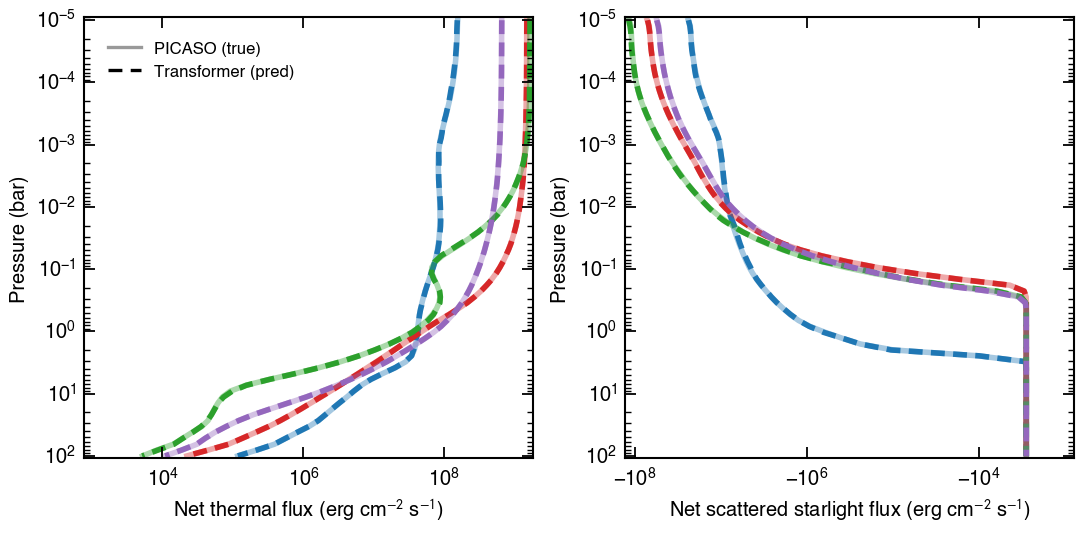

In [12]:
if MODEL_PRESENT:
    from torch.utils.data import DataLoader
    from dataset import create_collate_fn, create_dataset
    from normalizer import DataNormalizer
    from matplotlib.ticker import FixedLocator, NullLocator, LogFormatterSciNotation

    NUM_PROFILES_TO_PLOT = 4
    PROFILE_LINE_COLORS = ("#1f77b4", "#d62728", "#2ca02c", "#9467bd")
    START_INDEX = 0

    # Fixed symlog x ticks, separated by panel.
    # Left panel plots positive flux data; right panel plots negative flux data.
    POS_FLUX_XTICKS = [1e4, 1e6, 1e8, 1e10]
    NEG_FLUX_XTICKS = [-1e10, -1e8, -1e6, -1e4]

    # Easy-to-edit x limits for the two flux panels.
    # Keep a small amount of opposite-sign space around zero for visual breathing room.
    THERMAL_XLIM = (-1e4, None)     # left panel: slightly negative to auto positive max
    REFLECTED_XLIM = (None, 1e4)    # right panel: auto negative min to slightly positive

    def set_fixed_flux_ticks(ax, xticks):
        ax.xaxis.set_major_locator(FixedLocator(xticks))
        ax.xaxis.set_major_formatter(LogFormatterSciNotation(linthresh=1e4))
        ax.xaxis.set_minor_locator(NullLocator())
        ax.tick_params(axis="x", which="minor", bottom=False, top=False)


    def denormalize_channel(values: Tensor, var_name: str, norm_meta: Dict[str, Any]) -> Tensor:
        method = norm_meta["normalization_methods"][var_name]
        stats = norm_meta["per_key_stats"][var_name]
        if method != "bool" and stats:
            return DataNormalizer.denormalize_tensor(values, method, stats)
        return values


    def denormalize_batch(config, norm_meta, inputs_norm, masks, targets_norm, target_masks):
        ds = config["data_specification"]
        in_vars, glob_vars, tgt_vars = ds["input_variables"], ds["global_variables"], ds["target_variables"]
        pad = float(ds["padding_value"])

        seq_norm = inputs_norm["sequence"].to(dtype=torch.float32)
        seq_mask = masks["sequence"].bool()
        seq_phys = torch.empty_like(seq_norm)

        for j, n in enumerate(in_vars):
            seq_phys[..., j] = denormalize_channel(seq_norm[..., j], n, norm_meta).to(torch.float32)

        seq_phys[seq_mask] = pad

        glob_phys = None
        if glob_vars and "global_features" in inputs_norm:
            gn = inputs_norm["global_features"].to(torch.float32)
            glob_phys = torch.empty_like(gn)

            for j, n in enumerate(glob_vars):
                glob_phys[..., j] = denormalize_channel(gn[..., j], n, norm_meta).to(torch.float32)

        tgt_phys = torch.empty_like(targets_norm.to(torch.float32))
        tgt_mask = target_masks.bool()

        for j, n in enumerate(tgt_vars):
            tgt_phys[..., j] = denormalize_channel(
                targets_norm[..., j].to(torch.float32), n, norm_meta
            ).to(torch.float32)

        tgt_phys[tgt_mask] = pad

        return seq_phys, glob_phys, tgt_phys, tgt_mask


    norm_meta = json.load(open(NORM_META_PATH, "r"))
    padding_value = float(train_config["data_specification"]["padding_value"])
    padding_epsilon = float(train_config["normalization"]["padding_comparison_epsilon"])

    with (PROC_TEST / "metadata.json").open("r") as f:
        test_total = int(json.load(f)["total_samples"])

    selected = list(range(START_INDEX, min(START_INDEX + NUM_PROFILES_TO_PLOT, test_total)))

    ds_obj = create_dataset(PROC_TEST, train_config, indices=selected)
    loader = DataLoader(
        ds_obj,
        batch_size=len(selected),
        shuffle=False,
        collate_fn=create_collate_fn(padding_value, padding_epsilon),
    )

    inputs_norm, masks, targets_norm, target_masks = next(iter(loader))
    seq_phys, glob_phys, tgt_phys, tgt_mask = denormalize_batch(
        train_config,
        norm_meta,
        inputs_norm,
        masks,
        targets_norm,
        target_masks,
    )

    # Load .pt2 program once and reuse module.
    program = torch.export.load(str(STANDALONE_PT2))
    model = program.module().to("cpu")

    with torch.inference_mode():
        pred_phys = model(
            sequence_phys=seq_phys.to(torch.float32).cpu(),
            global_features_phys=(
                glob_phys.to(torch.float32).cpu()
                if glob_phys is not None
                else None
            ),
        )

    input_vars = train_config["data_specification"]["input_variables"]
    target_vars = train_config["data_specification"]["target_variables"]

    pressure_idx = input_vars.index("pressure_bar") if "pressure_bar" in input_vars else None
    thermal_idx = target_vars.index("net_thermal_flux") if "net_thermal_flux" in target_vars else None
    reflected_idx = target_vars.index("net_reflected_flux") if "net_reflected_flux" in target_vars else None

    fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
    (axes if isinstance(axes, np.ndarray) else np.array([axes])).ravel()  # no-op shim

    for _ax in plt.gcf().axes:
        _ax.grid(False, which="both")

    ax_t, ax_r = axes

    for k, sample_idx in enumerate(selected):
        valid = (~tgt_mask[k]).cpu().numpy()

        if not valid.any():
            continue

        p = pred_phys[k].cpu().numpy()[valid]
        t = tgt_phys[k].cpu().numpy()[valid]

        pr_vals = (
            seq_phys[k, :, pressure_idx].cpu().numpy()[valid]
            if pressure_idx is not None
            else np.arange(valid.sum())
        )

        color = PROFILE_LINE_COLORS[k % len(PROFILE_LINE_COLORS)]

        if thermal_idx is not None:
            yt_t, yt_p = t[:, thermal_idx], p[:, thermal_idx]

            # Plot all thermal flux values; visible range is controlled only by THERMAL_XLIM.
            ax_t.plot(
                yt_t,
                pr_vals,
                color=color,
                alpha=0.4,
                linewidth=4,
            )
            ax_t.plot(
                yt_p,
                pr_vals,
                color=color,
                linestyle=(0, (10, 6)),
                linewidth=4,
            )

        if reflected_idx is not None:
            yr_t, yr_p = t[:, reflected_idx], p[:, reflected_idx]

            # Plot all reflected/scattered flux values; visible range is controlled only by REFLECTED_XLIM.
            ax_r.plot(
                yr_t,
                pr_vals,
                color=color,
                alpha=0.4,
                linewidth=4,
            )
            ax_r.plot(
                yr_p,
                pr_vals,
                color=color,
                linestyle=(0, (10, 6)),
                linewidth=4,
            )

    # Collect masked flux + pressure data for data-driven axis limits.
    _valid_np = (~tgt_mask).cpu().numpy().astype(bool)

    _pres_data = (
        seq_phys[..., pressure_idx].cpu().numpy()[_valid_np]
        if pressure_idx is not None
        else np.array([])
    )

    def _chan(arr_t, ch):
        if ch is None:
            return np.array([])
        return arr_t[..., ch].cpu().numpy()[_valid_np]

    _thermal_all = np.concatenate([
        _chan(tgt_phys, thermal_idx),
        _chan(pred_phys, thermal_idx),
    ])
    _reflected_all = np.concatenate([
        _chan(tgt_phys, reflected_idx),
        _chan(pred_phys, reflected_idx),
    ])

    # Use all flux values for autoscaling, then crop the visible range with THERMAL_XLIM/REFLECTED_XLIM.
    _flux_data = {
        "thermal": _thermal_all,
        "reflected": _reflected_all,
    }

    for ax, label, fkey, xticks, xlim in (
        (ax_t, "Net thermal flux (erg cm$^{-2}$ s$^{-1}$)", "thermal", POS_FLUX_XTICKS, THERMAL_XLIM),
        (ax_r, "Net scattered starlight flux (erg cm$^{-2}$ s$^{-1}$)", "reflected", NEG_FLUX_XTICKS, REFLECTED_XLIM),
    ):
        # Symlog x for flux, with easy-to-edit limits set above.
        pad_symlog_lim(ax, _flux_data[fkey], axis="x", linthresh=1e4, linscale=0.5)
        ax.set_xlim(left=xlim[0], right=xlim[1])
        set_fixed_flux_ticks(ax, xticks)

        if _pres_data.size:
            pad_log_lim(ax, _pres_data, axis="y", invert=True)

        ax.set_ylabel("Pressure (bar)")
        ax.set_xlabel(label)

    ax_t.legend(
        handles=[
            Line2D([0], [0], color="black", alpha=0.4, linewidth=2.4, label="PICASO (true)"),
            Line2D([0], [0], color="black", linestyle=(0, (10, 6)), linewidth=2.4, label="Transformer (pred)"),
        ],
        loc="best",
    )

    fig.tight_layout()
    out = FIGS_DIR / "reviewer_fig_profiles.png"

    cap_ticks_all(8)

    # cap_ticks_all can modify tick locators/limits, so force the x settings again afterward.
    ax_t.set_xlim(left=THERMAL_XLIM[0], right=THERMAL_XLIM[1])
    ax_r.set_xlim(left=REFLECTED_XLIM[0], right=REFLECTED_XLIM[1])
    set_fixed_flux_ticks(ax_t, POS_FLUX_XTICKS)
    set_fixed_flux_ticks(ax_r, NEG_FLUX_XTICKS)

    fig.savefig(out, dpi=220, bbox_inches="tight")
    print(f"Wrote {out}")
    plt.show()

else:
    print("Skipped figure 10 (example test profiles) — needs trained model + .pt2 export.")

Wrote /Users/imalsky/Desktop/Emulators/RT-Project/Problemulator_extra_runs/testing/figs_final/reviewer_fig_profiles_lstm.png


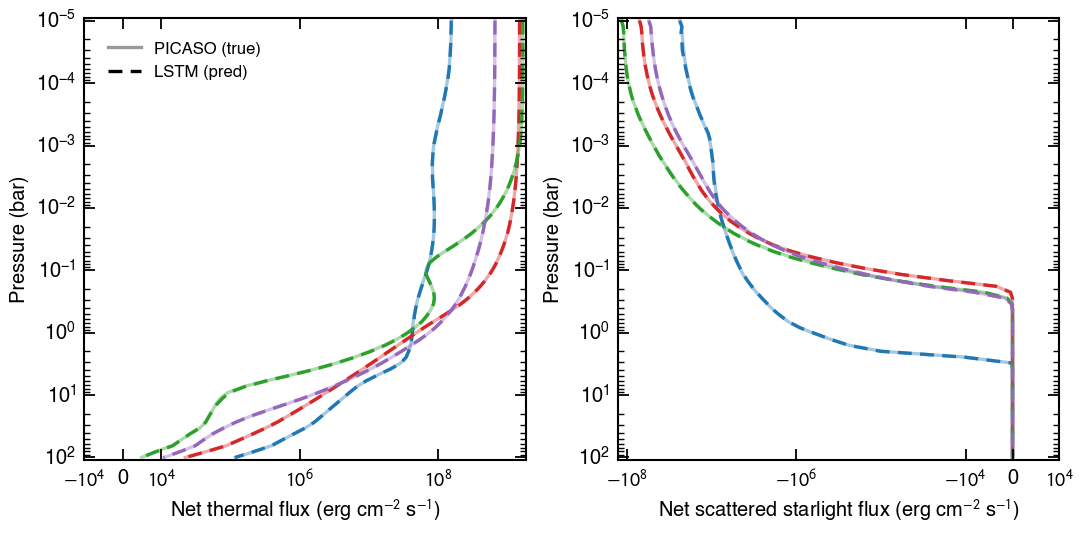

Wrote /Users/imalsky/Desktop/Emulators/RT-Project/Problemulator_extra_runs/testing/figs_final/reviewer_fig_profiles_comparison.png


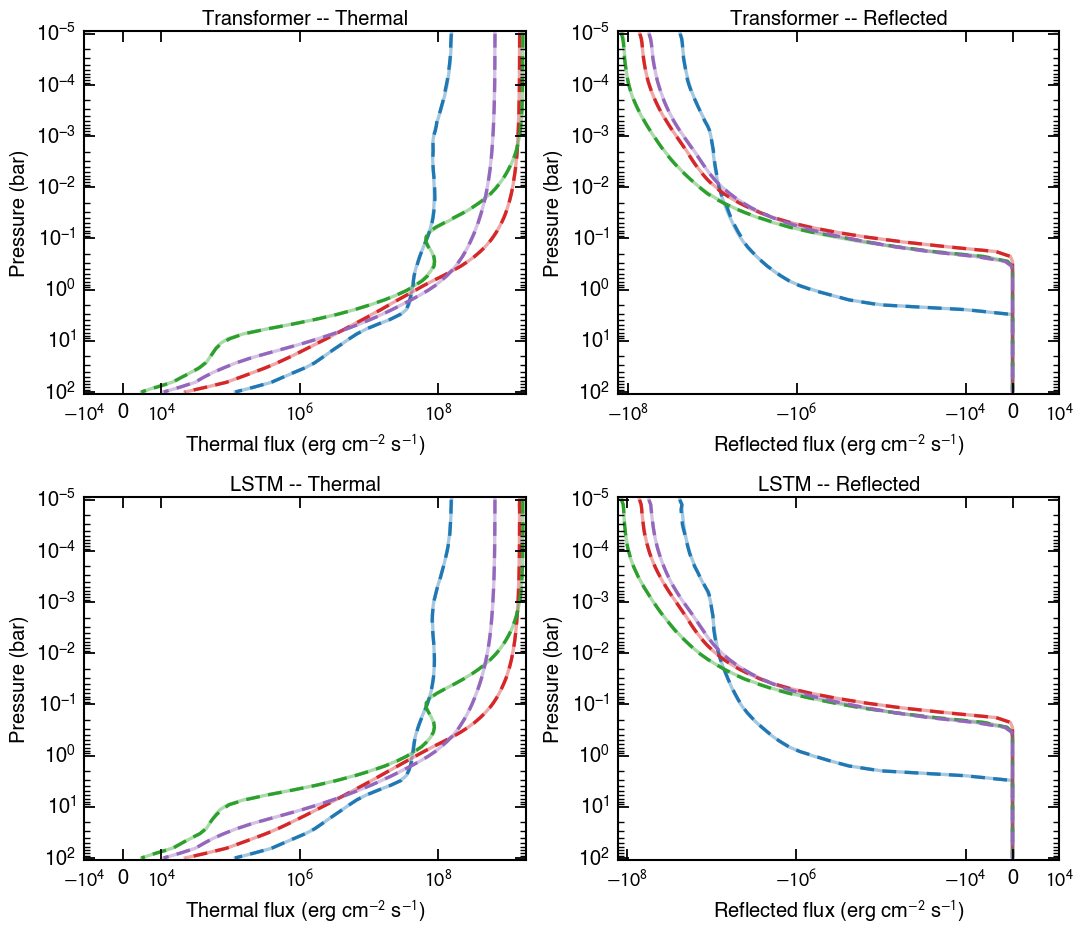

In [13]:
# LSTM profile predictions + 2-row comparison (transformer | LSTM).
if LSTM_MODEL_PRESENT:
    selected_l = list(range(0, min(4, int(json.load(open(PROC_TEST / "metadata.json"))["total_samples"]))))
    ds_obj_l = create_dataset(PROC_TEST, lstm_train_config, indices=selected_l)
    loader_l = DataLoader(
        ds_obj_l, batch_size=len(selected_l), shuffle=False,
        collate_fn=create_collate_fn(padding_value, padding_epsilon),
    )
    in_norm_l, msk_l, tgt_norm_l, tgt_msk_l = next(iter(loader_l))
    sp_l, gp_l, tp_l, tm_l = denormalize_batch(lstm_train_config, norm_meta, in_norm_l, msk_l, tgt_norm_l, tgt_msk_l)
    model_l_inf = load_inference_module(LSTM_MODEL_DIR)
    pp_l = predict_physical(model_l_inf, sp_l, gp_l)

    iv = lstm_train_config["data_specification"]["input_variables"]
    tv = lstm_train_config["data_specification"]["target_variables"]
    p_idx = iv.index("pressure_bar")
    th_idx = tv.index("net_thermal_flux")
    rf_idx = tv.index("net_reflected_flux")
    PROFILE_LINE_COLORS_LF = ("#1f77b4", "#d62728", "#2ca02c", "#9467bd")

    # Easy-to-change displayed x-limits.
    # These affect only the visible axis range; they do not filter plotted data.
    THERMAL_XLIM_LF = (-1e4, None)    # first/thermal panel: slightly negative, auto positive max
    REFLECTED_XLIM_LF = (None, 1e4)   # second/reflected panel: auto negative min, slightly positive

    def apply_profile_flux_xlims(ax_thermal, ax_reflected):
        ax_thermal.set_xlim(*THERMAL_XLIM_LF)
        ax_reflected.set_xlim(*REFLECTED_XLIM_LF)

    fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
    ax_t, ax_r = axes
    for k, _idx in enumerate(selected_l):
        valid = (~tm_l[k]).cpu().numpy()
        if not valid.any():
            continue
        p = pp_l[k].cpu().numpy()[valid]
        t = tp_l[k].cpu().numpy()[valid]
        pr = sp_l[k, :, p_idx].cpu().numpy()[valid]
        c = PROFILE_LINE_COLORS_LF[k % len(PROFILE_LINE_COLORS_LF)]
        yt_t, yt_p = t[:, th_idx], p[:, th_idx]
        ax_t.plot(yt_t, pr, color=c, alpha=0.4, linewidth=2.4)
        ax_t.plot(yt_p, pr, color=c, linestyle=(0, (10, 6)), linewidth=2.4)
        yr_t, yr_p = t[:, rf_idx], p[:, rf_idx]
        ax_r.plot(yr_t, pr, color=c, alpha=0.4, linewidth=2.4)
        ax_r.plot(yr_p, pr, color=c, linestyle=(0, (10, 6)), linewidth=2.4)
    # Data-driven scale + limits (symlog x for flux, log inverted y for pressure).
    _vm = (~tm_l).cpu().numpy().astype(bool)
    _pdat = sp_l[..., p_idx].cpu().numpy()[_vm]
    _thdat = np.concatenate([tp_l[..., th_idx].cpu().numpy()[_vm], pp_l[..., th_idx].cpu().numpy()[_vm]])
    _rfdat = np.concatenate([tp_l[..., rf_idx].cpu().numpy()[_vm], pp_l[..., rf_idx].cpu().numpy()[_vm]])
    for ax, lbl, fdat in ((ax_t, "Net thermal flux", _thdat), (ax_r, "Net scattered starlight flux", _rfdat)):
        pad_symlog_lim(ax, fdat, axis="x", linthresh=1e4, linscale=0.5)
        pad_log_lim(ax, _pdat, axis="y", invert=True)
        ax.set_ylabel("Pressure (bar)"); ax.set_xlabel(f"{lbl} (erg cm$^{{-2}}$ s$^{{-1}}$)")
    apply_profile_flux_xlims(ax_t, ax_r)
    ax_t.legend(handles=[
        Line2D([0], [0], color="black", alpha=0.4, linewidth=2.4, label="PICASO (true)"),
        Line2D([0], [0], color="black", linestyle=(0, (10, 6)), linewidth=2.4, label="LSTM (pred)"),
    ], loc="best")
    fig.tight_layout()
    out_lstm = FIGS_DIR / "reviewer_fig_profiles_lstm.png"
    cap_ticks_all(8)
    apply_profile_flux_xlims(ax_t, ax_r)
    fig.savefig(out_lstm, dpi=220, bbox_inches="tight")
    print(f"Wrote {out_lstm}"); plt.show()

    # 2-row comparison: transformer (top) vs LSTM (bottom)
    if MODEL_PRESENT:
        ds_obj_t = create_dataset(PROC_TEST, train_config, indices=selected_l)
        loader_t = DataLoader(ds_obj_t, batch_size=len(selected_l), shuffle=False, collate_fn=create_collate_fn(padding_value, padding_epsilon))
        in_norm_t, msk_t, tgt_norm_t, tgt_msk_t = next(iter(loader_t))
        sp_t, gp_t, tp_t, tm_t = denormalize_batch(train_config, norm_meta, in_norm_t, msk_t, tgt_norm_t, tgt_msk_t)
        model_t_inf = load_inference_module(MODEL_DIR)
        pp_t = predict_physical(model_t_inf, sp_t, gp_t)

        fig, axes2 = plt.subplots(2, 2, figsize=(11, 9.5))
        for row_idx, (arch, pp, tp, tm, sp) in enumerate([
            ("transformer", pp_t, tp_t, tm_t, sp_t),
            ("lstm", pp_l, tp_l, tm_l, sp_l),
        ]):
            ax_t2, ax_r2 = axes2[row_idx]
            for k, _idx in enumerate(selected_l):
                valid = (~tm[k]).cpu().numpy()
                if not valid.any():
                    continue
                p = pp[k].cpu().numpy()[valid]
                t = tp[k].cpu().numpy()[valid]
                pr = sp[k, :, p_idx].cpu().numpy()[valid]
                c = PROFILE_LINE_COLORS_LF[k % len(PROFILE_LINE_COLORS_LF)]
                yt_t, yt_p = t[:, th_idx], p[:, th_idx]
                ax_t2.plot(yt_t, pr, color=c, alpha=0.4, linewidth=2.4)
                ax_t2.plot(yt_p, pr, color=c, linestyle=(0, (10, 6)), linewidth=2.4)
                yr_t, yr_p = t[:, rf_idx], p[:, rf_idx]
                ax_r2.plot(yr_t, pr, color=c, alpha=0.4, linewidth=2.4)
                ax_r2.plot(yr_p, pr, color=c, linestyle=(0, (10, 6)), linewidth=2.4)
            _vm2 = (~tm).cpu().numpy().astype(bool)
            _pdat2 = sp[..., p_idx].cpu().numpy()[_vm2]
            _thd2 = np.concatenate([tp[..., th_idx].cpu().numpy()[_vm2], pp[..., th_idx].cpu().numpy()[_vm2]])
            _rfd2 = np.concatenate([tp[..., rf_idx].cpu().numpy()[_vm2], pp[..., rf_idx].cpu().numpy()[_vm2]])
            for ax, lbl, fd in ((ax_t2, "Thermal", _thd2), (ax_r2, "Reflected", _rfd2)):
                pad_symlog_lim(ax, fd, axis="x", linthresh=1e4, linscale=0.5)
                pad_log_lim(ax, _pdat2, axis="y", invert=True)
                ax.set_ylabel("Pressure (bar)")
                ax.set_xlabel(f"{lbl} flux (erg cm$^{{-2}}$ s$^{{-1}}$)")
                ax.set_title(f"{MODELS[arch]['label']} -- {lbl}")
            apply_profile_flux_xlims(ax_t2, ax_r2)
        fig.tight_layout()
        out_cmp = FIGS_DIR / "reviewer_fig_profiles_comparison.png"
        cap_ticks_all(8)
        for _row_axes in axes2:
            apply_profile_flux_xlims(_row_axes[0], _row_axes[1])
        fig.savefig(out_cmp, dpi=220, bbox_inches="tight")
        print(f"Wrote {out_cmp}"); plt.show()
else:
    print("Skipped LSTM profile figures - LSTM model or .pt2 missing.")

In [14]:
if MODEL_PRESENT:
    from tqdm import tqdm

    PCT_DENOM_FLOOR = 1.0
    ERR_BATCH_SIZE = 1024
    DEVICE_ERR = torch.device("cpu")
    ERR_MAX_BATCHES = 8 # int(os.environ.get("ERR_MAX_BATCHES", "10"))

    program_err = torch.export.load(str(STANDALONE_PT2))
    model_err = program_err.module().to(DEVICE_ERR)

    with (PROC_TEST / "metadata.json").open("r") as f:
        total_samples = int(json.load(f)["total_samples"])

    ds_full = create_dataset(PROC_TEST, train_config, list(range(total_samples)))
    loader_full = DataLoader(
        ds_full, batch_size=ERR_BATCH_SIZE, shuffle=False,
        collate_fn=create_collate_fn(padding_value, padding_epsilon), drop_last=False,
    )

    target_vars = train_config["data_specification"]["target_variables"]
    flux_vars = [n for n in ("net_thermal_flux", "net_reflected_flux") if n in target_vars]
    flux_idx = {n: target_vars.index(n) for n in flux_vars}

    acc = {n: {"diff_chunks": [], "true_chunks": [], "pred_chunks": [], "pressure_chunks": []} for n in flux_vars}
    input_vars = train_config["data_specification"]["input_variables"]
    pressure_idx = input_vars.index("pressure_bar") if "pressure_bar" in input_vars else None

    for b_idx, (inputs_norm, masks, targets_norm, target_masks) in enumerate(tqdm(loader_full, desc="Test batches")):
        if ERR_MAX_BATCHES and b_idx >= ERR_MAX_BATCHES:
            break
        seq_phys_b, glob_phys_b, tgt_phys_b, tgt_mask_b = denormalize_batch(
            train_config, norm_meta, inputs_norm, masks, targets_norm, target_masks,
        )
        with torch.inference_mode():
            pred_phys_b = model_err(
                sequence_phys=seq_phys_b.to(torch.float32).cpu(),
                global_features_phys=(glob_phys_b.to(torch.float32).cpu() if glob_phys_b is not None else None),
            )
        valid = (~tgt_mask_b)
        pressure_phys = seq_phys_b[..., pressure_idx] if pressure_idx is not None else None

        for n in flux_vars:
            i = flux_idx[n]
            p = pred_phys_b[..., i][valid]
            t = tgt_phys_b[..., i][valid]
            if p.numel() == 0:
                continue
            acc[n]["diff_chunks"].append((p - t).cpu().numpy())
            acc[n]["true_chunks"].append(t.cpu().numpy())
            acc[n]["pred_chunks"].append(p.cpu().numpy())
            if pressure_phys is not None:
                acc[n]["pressure_chunks"].append(pressure_phys[valid].cpu().numpy())

    per_channel = {}
    for n in flux_vars:
        diffs = np.concatenate(acc[n]["diff_chunks"]) if acc[n]["diff_chunks"] else np.array([])
        truths = np.concatenate(acc[n]["true_chunks"]) if acc[n]["true_chunks"] else np.array([])
        if diffs.size == 0:
            continue
        per_channel[n] = {
            "n_points": int(diffs.size),
            "mae": float(np.mean(np.abs(diffs))),
            "rmse": float(np.sqrt(np.mean(diffs ** 2))),
            "r2": float(1.0 - np.sum(diffs ** 2) / max(np.sum((truths - truths.mean()) ** 2), 1e-30)),
        }
    print("Per-channel test errors (in-memory only; not written to disk):")
    for n, s in per_channel.items():
        print(f"  {n}: MAE={s['mae']:.3e}, RMSE={s['rmse']:.3e}, R^2={s['r2']:.6f}")

    ERR_RAW = {
        n: {
            "diffs": np.concatenate(acc[n]["diff_chunks"]) if acc[n]["diff_chunks"] else np.array([]),
            "truths": np.concatenate(acc[n]["true_chunks"]) if acc[n]["true_chunks"] else np.array([]),
            "preds":  np.concatenate(acc[n]["pred_chunks"]) if acc[n]["pred_chunks"] else np.array([]),
            "pressures": np.concatenate(acc[n]["pressure_chunks"]) if acc[n]["pressure_chunks"] else np.array([]),
        }
        for n in flux_vars
    }
else:
    print("Skipped per-channel test-error computation - needs trained model + .pt2 export.")

Test batches:   0%|          | 0/733 [00:00<?, ?it/s]

Test batches:   0%|          | 1/733 [00:02<24:33,  2.01s/it]

Test batches:   0%|          | 2/733 [00:03<24:11,  1.99s/it]

Test batches:   0%|          | 3/733 [00:05<24:03,  1.98s/it]

Test batches:   1%|          | 4/733 [00:07<24:01,  1.98s/it]

...

Test batches:   1%|          | 6/733 [00:11<23:53,  1.97s/it]

Test batches:   1%|          | 7/733 [00:13<23:50,  1.97s/it]

Test batches:   1%|          | 8/733 [00:15<23:49,  1.97s/it]

Test batches:   1%|          | 8/733 [00:15<23:52,  1.98s/it]

Per-channel test errors (in-memory only; not written to disk):
  net_thermal_flux: MAE=1.401e+06, RMSE=4.136e+06, R^2=0.999954
  net_reflected_flux: MAE=1.313e+05, RMSE=3.754e+05, R^2=0.999914


In [15]:
# LSTM per-channel test errors + write per_channel_test_errors.json with both
# architectures (R1.4 follow-on).
if LSTM_MODEL_PRESENT:
    ERR_RAW_LSTM = compute_err_raw(LSTM_MODEL_DIR, lstm_train_config)
    per_channel_lstm = summarize_err_raw(ERR_RAW_LSTM)
    print("LSTM per-channel test errors:")
    for n, s in per_channel_lstm.items():
        print(f"  {n}: MAE={s['mae']:.3e}, RMSE={s['rmse']:.3e}, R^2={s['r2']:.6f}, bias={s['bias']:.3e}")
else:
    ERR_RAW_LSTM = {}
    per_channel_lstm = {}
    print("Skipped LSTM per-channel error computation - LSTM not ready.")

per_channel_all = {}
if MODEL_PRESENT and per_channel:
    per_channel_all["transformer"] = per_channel
if LSTM_MODEL_PRESENT and per_channel_lstm:
    per_channel_all["lstm"] = per_channel_lstm
if per_channel_all:
    pce_path = OUTPUTS_DIR / "per_channel_test_errors.json"
    with pce_path.open("w") as f:
        json.dump(per_channel_all, f, indent=2)
    print(f"Wrote {pce_path.name}")


Test batches:   0%|          | 0/733 [00:00<?, ?it/s]

Test batches:   0%|          | 1/733 [00:02<28:19,  2.32s/it]

Test batches:   0%|          | 2/733 [00:04<27:33,  2.26s/it]

Test batches:   0%|          | 3/733 [00:06<27:12,  2.24s/it]

Test batches:   1%|          | 4/733 [00:09<27:17,  2.25s/it]

...

Test batches:   1%|          | 8/733 [00:17<27:05,  2.24s/it]

Test batches:   1%|          | 9/733 [00:20<27:09,  2.25s/it]

Test batches:   1%|▏         | 10/733 [00:22<27:05,  2.25s/it]

Test batches:   1%|▏         | 10/733 [00:22<27:06,  2.25s/it]

LSTM per-channel test errors:
  net_thermal_flux: MAE=6.937e+05, RMSE=2.462e+06, R^2=0.999984, bias=8.865e+04
  net_reflected_flux: MAE=8.041e+04, RMSE=2.481e+05, R^2=0.999964, bias=-5.097e+04
Wrote per_channel_test_errors.json


## 15. Figure: residual + energy-balance diagnostic (R1.4, R1.5)

Top row: predicted-vs-true scatter with y=x line per channel. Bottom row: residual histogram per channel and a per-profile integrated-flux relative-error histogram (energy-balance check). Strengthens the no-memorization argument.

Wrote /Users/imalsky/Desktop/Emulators/RT-Project/Problemulator_extra_runs/testing/figs_final/reviewer_fig_residuals.png


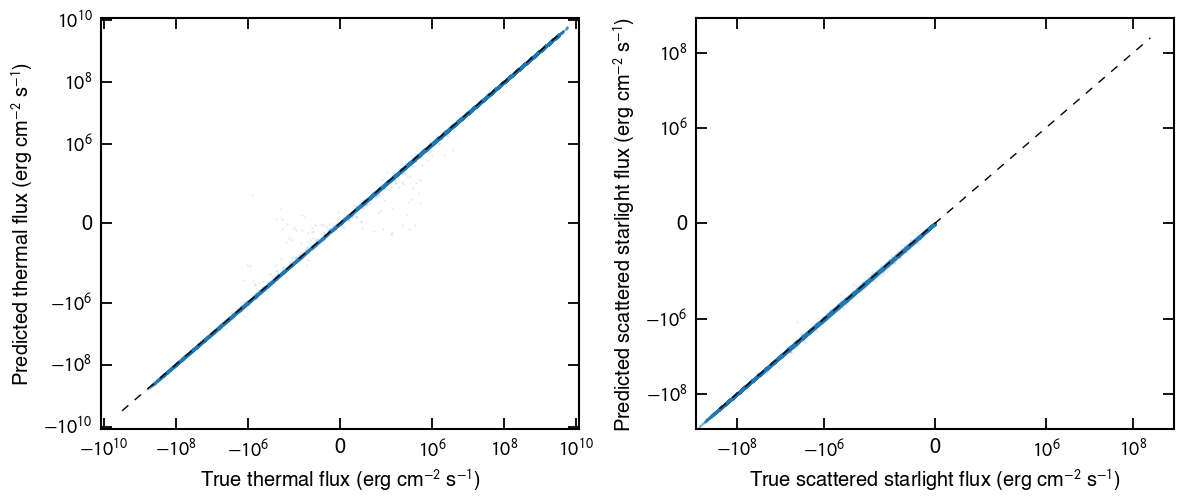

In [16]:
if MODEL_PRESENT:
    from matplotlib.ticker import FixedLocator, NullLocator

    # Set these separately.
    # Use None to let Matplotlib choose automatically.
    RESIDUAL_XTICKS = [-1e10, -1e8, -1e6, 0.0, 1e6, 1e8, 1e10]
    RESIDUAL_YTICKS = [-1e10, -1e8, -1e6, 0.0, 1e6, 1e8, 1e10]

    def apply_residual_ticks(ax, xticks=None, yticks=None):
        if xticks is not None:
            ax.xaxis.set_major_locator(FixedLocator(xticks))
            ax.xaxis.set_minor_locator(NullLocator())

        if yticks is not None:
            ax.yaxis.set_major_locator(FixedLocator(yticks))
            ax.yaxis.set_minor_locator(NullLocator())

    def downsample(arr: np.ndarray, n: int = 200_000, seed: int = 0) -> np.ndarray:
        if arr.size <= n:
            return arr
        rng = np.random.default_rng(seed)
        idx = rng.choice(arr.size, n, replace=False)
        return arr[idx]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))
    (axes if isinstance(axes, np.ndarray) else np.array([axes])).ravel()  # no-op shim

    for _ax in plt.gcf().axes:
        _ax.grid(False, which="both")

    for col, name, flux_label in (
        (0, "net_thermal_flux", "thermal flux"),
        (1, "net_reflected_flux", "scattered starlight flux"),
    ):
        ax = axes[col]

        if name not in ERR_RAW or ERR_RAW[name]["truths"].size == 0:
            ax.set_axis_off()
            continue

        truths = downsample(ERR_RAW[name]["truths"])
        preds = downsample(ERR_RAW[name]["preds"])

        ax.scatter(truths, preds, s=1, alpha=0.07, color="#1f77b4")

        _all = np.concatenate([truths, preds])
        lim = float(np.percentile(np.abs(_all), 99.5))

        if np.isfinite(lim) and lim > 0:
            ax.plot(
                [-lim, lim],
                [-lim, lim],
                color="black",
                linewidth=1.0,
                linestyle="--",
            )

        # Flux spans many decades and includes negatives -> symlog both axes.
        # 1.1 * percentile(99.5, |.|) on each side, linear band hides the noise floor.
        _lt = max(1e4, lim / 1e6)

        pad_symlog_lim(ax, _all, axis="x", linthresh=_lt, linscale=0.5)
        pad_symlog_lim(ax, _all, axis="y", linthresh=_lt, linscale=0.5)

        # Apply x/y ticks separately.
        apply_residual_ticks(
            ax,
            xticks=RESIDUAL_XTICKS,
            yticks=RESIDUAL_YTICKS,
        )

        ax.grid(False)
        ax.set_xlabel(f"True {flux_label} (erg cm$^{{-2}}$ s$^{{-1}}$)")
        ax.set_ylabel(f"Predicted {flux_label} (erg cm$^{{-2}}$ s$^{{-1}}$)")

    out = FIGS_DIR / "reviewer_fig_residuals.png"

    cap_ticks_all(8)

    # cap_ticks_all can overwrite tick locators, so apply custom x/y ticks again.
    for ax in axes:
        if ax.axison:
            apply_residual_ticks(
                ax,
                xticks=RESIDUAL_XTICKS,
                yticks=RESIDUAL_YTICKS,
            )

    fig.tight_layout()
    fig.savefig(out, dpi=220, bbox_inches="tight")
    print(f"Wrote {out}")
    plt.show()

else:
    print("Skipped residual diagnostic - needs ERR_RAW from previous section.")

Wrote /Users/imalsky/Desktop/Emulators/RT-Project/Problemulator_extra_runs/testing/figs_final/reviewer_fig_residuals_lstm.png


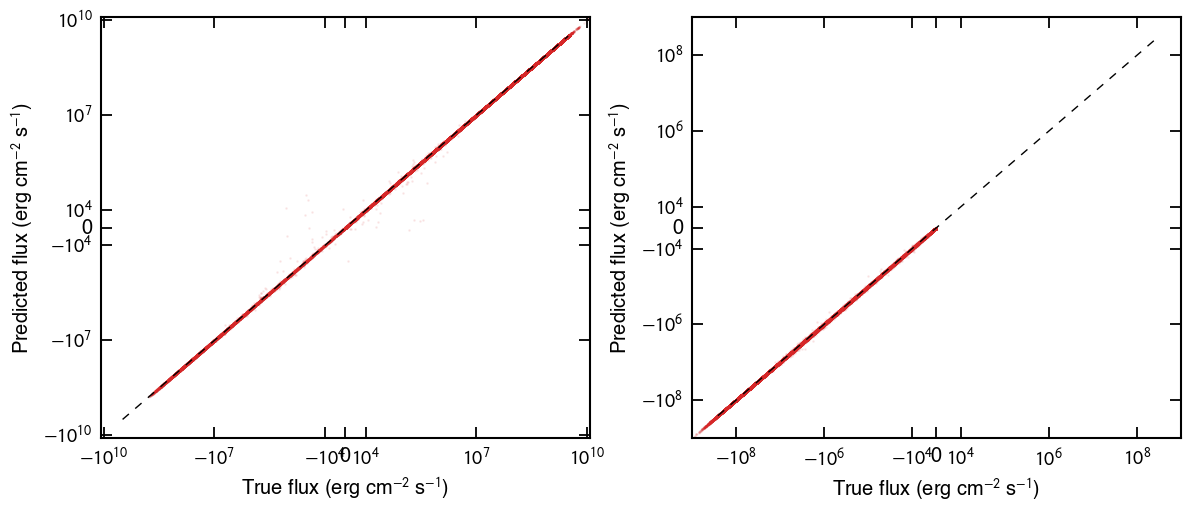

Wrote /Users/imalsky/Desktop/Emulators/RT-Project/Problemulator_extra_runs/testing/figs_final/reviewer_fig_residuals_comparison.png


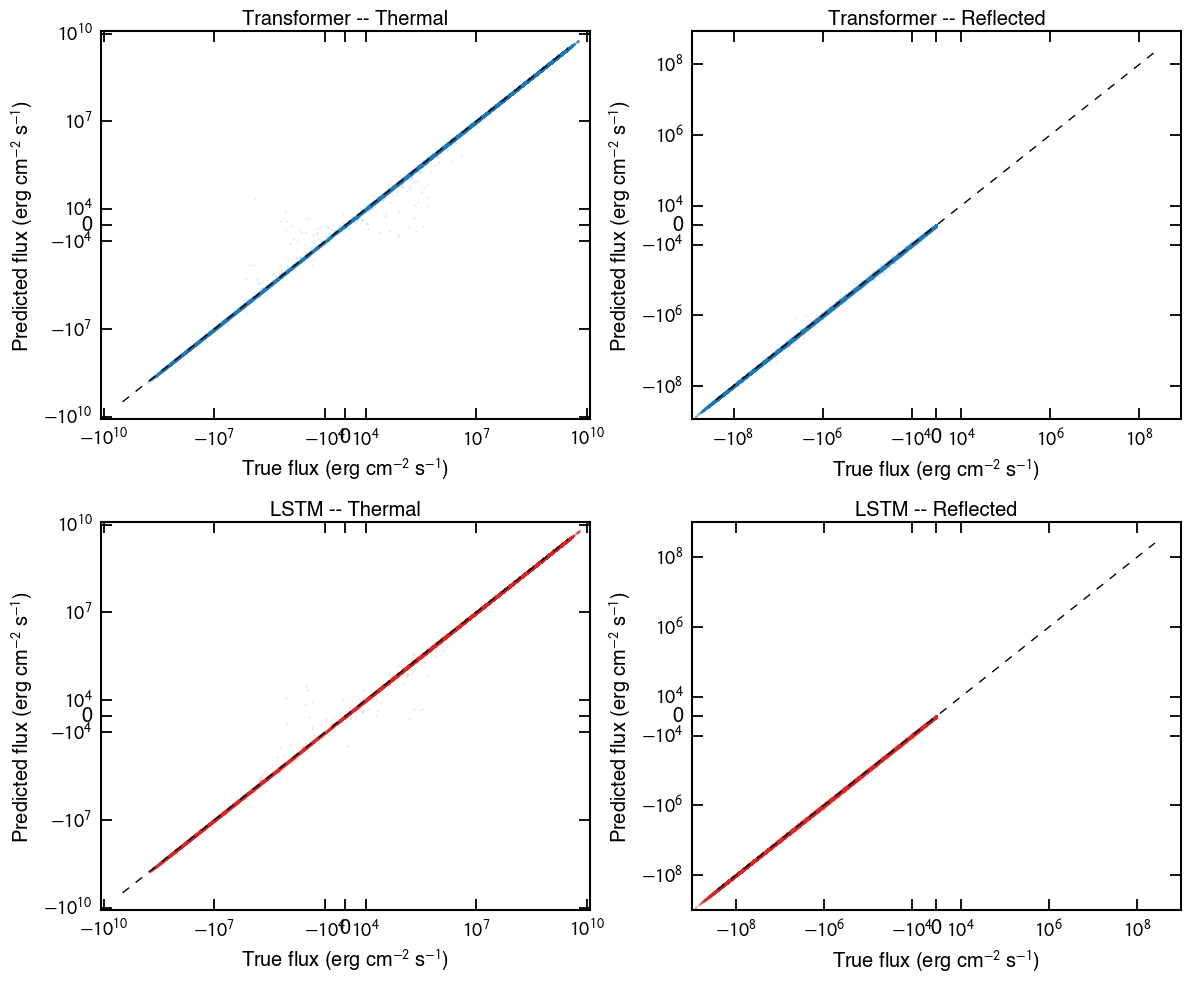

In [17]:
# LSTM residual scatter + 2-panel transformer-vs-LSTM comparison.
from matplotlib.ticker import MaxNLocator

def _downsample(arr, n=200_000, seed=0):
    if arr.size <= n:
        return arr
    rng = np.random.default_rng(seed)
    return arr[rng.choice(arr.size, n, replace=False)]

if LSTM_MODEL_PRESENT and ERR_RAW_LSTM:
    # LSTM-only residual figure
    fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))
    for col, name, _ in ((0, "net_thermal_flux", "Net thermal flux"),
                          (1, "net_reflected_flux", "Net scattered starlight flux")):
        ax = axes[col]
        if name not in ERR_RAW_LSTM or ERR_RAW_LSTM[name]["truths"].size == 0:
            ax.set_axis_off(); continue
        truths = _downsample(ERR_RAW_LSTM[name]["truths"])
        preds = _downsample(ERR_RAW_LSTM[name]["preds"])
        ax.scatter(truths, preds, s=1, alpha=0.07, color=MODELS["lstm"]["color"])
        _all = np.concatenate([truths, preds])
        lim = float(np.percentile(np.abs(_all), 99.5))
        if np.isfinite(lim) and lim > 0:
            ax.plot([-lim, lim], [-lim, lim], color="black", linewidth=1.0, linestyle="--")
        _lt = max(1e4, lim / 1e6)
        pad_symlog_lim(ax, _all, axis="x", linthresh=_lt, linscale=0.5)
        pad_symlog_lim(ax, _all, axis="y", linthresh=_lt, linscale=0.5)
        ax.set_xlabel("True flux (erg cm$^{-2}$ s$^{-1}$)")
        ax.set_ylabel("Predicted flux (erg cm$^{-2}$ s$^{-1}$)")
    fig.tight_layout()
    out_lstm = FIGS_DIR / "reviewer_fig_residuals_lstm.png"
    cap_ticks_all(8); fig.savefig(out_lstm, dpi=220, bbox_inches="tight")
    print(f"Wrote {out_lstm}"); plt.show()

    # 2x2 comparison (rows = architecture, cols = channel)
    if MODEL_PRESENT and "ERR_RAW" in dir():
        fig, axes2 = plt.subplots(2, 2, figsize=(12, 10))
        for row_idx, (arch, ERR) in enumerate([("transformer", ERR_RAW), ("lstm", ERR_RAW_LSTM)]):
            for col, name, lbl in ((0, "net_thermal_flux", "Thermal"),
                                    (1, "net_reflected_flux", "Reflected")):
                ax = axes2[row_idx, col]
                if name not in ERR or ERR[name]["truths"].size == 0:
                    ax.set_axis_off(); continue
                truths = _downsample(ERR[name]["truths"])
                preds = _downsample(ERR[name]["preds"])
                ax.scatter(truths, preds, s=1, alpha=0.07, color=MODELS[arch]["color"])
                _all = np.concatenate([truths, preds])
                lim = float(np.percentile(np.abs(_all), 99.5))
                if np.isfinite(lim) and lim > 0:
                    ax.plot([-lim, lim], [-lim, lim], color="black", linewidth=1.0, linestyle="--")
                _lt = max(1e4, lim / 1e6)
                pad_symlog_lim(ax, _all, axis="x", linthresh=_lt, linscale=0.5)
                pad_symlog_lim(ax, _all, axis="y", linthresh=_lt, linscale=0.5)
                ax.set_xlabel("True flux (erg cm$^{-2}$ s$^{-1}$)")
                ax.set_ylabel("Predicted flux (erg cm$^{-2}$ s$^{-1}$)")
                ax.set_title(f"{MODELS[arch]['label']} -- {lbl}")
        fig.tight_layout()
        out_cmp = FIGS_DIR / "reviewer_fig_residuals_comparison.png"
        cap_ticks_all(8); fig.savefig(out_cmp, dpi=220, bbox_inches="tight")
        print(f"Wrote {out_cmp}"); plt.show()
else:
    print("Skipped LSTM residuals - LSTM ERR_RAW missing.")


## 17. Sanity assertions and READY gate

## Atmospheric profiles 3-panel (raw H5, no predictions)


Saved: /Users/imalsky/Desktop/Emulators/RT-Project/Problemulator_extra_runs/testing/figs_final/atmospheric_profiles_3panel.png


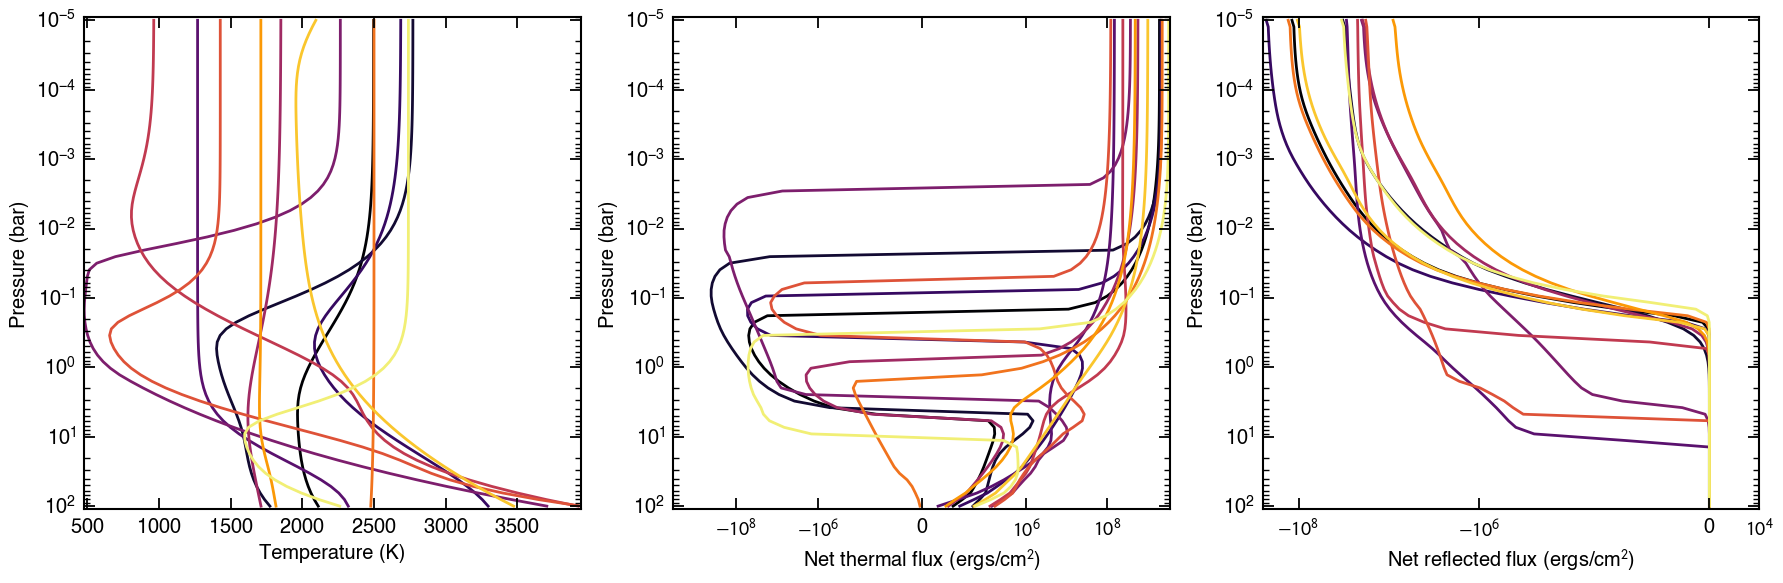

In [18]:
import h5py
from matplotlib.ticker import FixedLocator, NullLocator

PROFILE_INDICES = [0, 2, 3, 4, 6, 7, 8, 10, 12, 17, 18, 20]

# Choose x ticks separately for each panel.
# Use None to let Matplotlib choose automatically.
TEMP_XTICKS = None
THERMAL_XTICKS = [-1e10, -1e8, -1e6, 0.0, 1e6, 1e8, 1e10]

# Last panel: mostly negative, but goes slightly positive.
REFLECTED_XTICKS = [-1e10, -1e8, -1e6, 0.0, 1e4]
REFLECTED_XLIM = (None, 1e4)

def apply_xticks(ax, xticks=None):
    if xticks is not None:
        ax.xaxis.set_major_locator(FixedLocator(xticks))
        ax.xaxis.set_minor_locator(NullLocator())

with open(MODEL_DIR / "dataset_splits.json") as _f:
    _splits = json.load(_f)

if "file_stems" in _splits:
    _stems = _splits["file_stems"]
    test_pairs = [(_stems[s], i) for s, i in _splits["test"]]
else:
    test_pairs = _splits["test"]

h5_files = train_config["data_paths_config"]["hdf5_dataset_filename"]
if isinstance(h5_files, str):
    h5_files = [h5_files]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
(axes if isinstance(axes, np.ndarray) else np.array([axes])).ravel()  # no-op shim

for _ax in plt.gcf().axes:
    _ax.grid(False, which="both")

colors = plt.cm.inferno(np.linspace(0, 0.95, len(PROFILE_INDICES)))
_all_P, _all_T, _all_th, _all_rf = [], [], [], []

for plot_idx, profile_idx in enumerate(PROFILE_INDICES):
    if profile_idx >= len(test_pairs):
        continue

    stem, row = test_pairs[profile_idx]
    h5_match = next((h for h in h5_files if Path(h).stem == stem), h5_files[0])
    h5_path = PROJECT_ROOT / "data" / "raw" / h5_match

    if not h5_path.exists():
        continue

    with h5py.File(h5_path, "r") as f:
        T = f["temperature_k"][row]
        P = f["pressure_bar"][row]
        thermal = f["net_thermal_flux"][row]
        reflected = f["net_reflected_flux"][row]

    valid = (P > 0) & np.isfinite(P) & np.isfinite(T)

    axes[0].plot(
        T[valid],
        P[valid],
        color=colors[plot_idx],
        linewidth=2.0,
        label=f"#{profile_idx}",
    )
    axes[1].plot(
        thermal[valid],
        P[valid],
        color=colors[plot_idx],
        linewidth=2.0,
    )
    axes[2].plot(
        reflected[valid],
        P[valid],
        color=colors[plot_idx],
        linewidth=2.0,
    )

    _all_P.append(P[valid])
    _all_T.append(T[valid])
    _all_th.append(thermal[valid])
    _all_rf.append(reflected[valid])

_P_all = np.concatenate(_all_P) if _all_P else np.array([])
_T_all = np.concatenate(_all_T) if _all_T else np.array([])
_th_all = np.concatenate(_all_th) if _all_th else np.array([])
_rf_all = np.concatenate(_all_rf) if _all_rf else np.array([])

# Panel 1: linear T x-axis, log inverted pressure y-axis.
axes[0].set_xlabel("Temperature (K)")
axes[0].set_ylabel("Pressure (bar)")
pad_log_lim(axes[0], _P_all, axis="y", invert=True)
apply_xticks(axes[0], TEMP_XTICKS)

# Panel 2: symlog thermal flux x-axis, log inverted pressure y-axis.
axes[1].set_xlabel("Net thermal flux (ergs/cm$^2$)")
axes[1].set_ylabel("Pressure (bar)")
pad_symlog_lim(axes[1], _th_all, axis="x", linthresh=1e4, linscale=0.5)
pad_log_lim(axes[1], _P_all, axis="y", invert=True)
apply_xticks(axes[1], THERMAL_XTICKS)

# Panel 3: symlog reflected flux x-axis, log inverted pressure y-axis.
axes[2].set_xlabel("Net reflected flux (ergs/cm$^2$)")
axes[2].set_ylabel("Pressure (bar)")
pad_symlog_lim(axes[2], _rf_all, axis="x", linthresh=1e4, linscale=0.5)
axes[2].set_xlim(REFLECTED_XLIM)
pad_log_lim(axes[2], _P_all, axis="y", invert=True)
apply_xticks(axes[2], REFLECTED_XTICKS)

out = FIGS_DIR / "atmospheric_profiles_3panel.png"

cap_ticks_all(8)

# cap_ticks_all can overwrite locators/limits, so force your chosen x ticks/limits again.
apply_xticks(axes[0], TEMP_XTICKS)
apply_xticks(axes[1], THERMAL_XTICKS)
apply_xticks(axes[2], REFLECTED_XTICKS)
axes[2].set_xlim(REFLECTED_XLIM)

plt.tight_layout()
plt.savefig(out, dpi=150, bbox_inches="tight")
print(f"Saved: {out}")
plt.show()

## Atmospheric profiles 3-panel with predictions


Saved: /Users/imalsky/Desktop/Emulators/RT-Project/Problemulator_extra_runs/testing/figs_final/atmospheric_profiles_3panel_with_preds.png


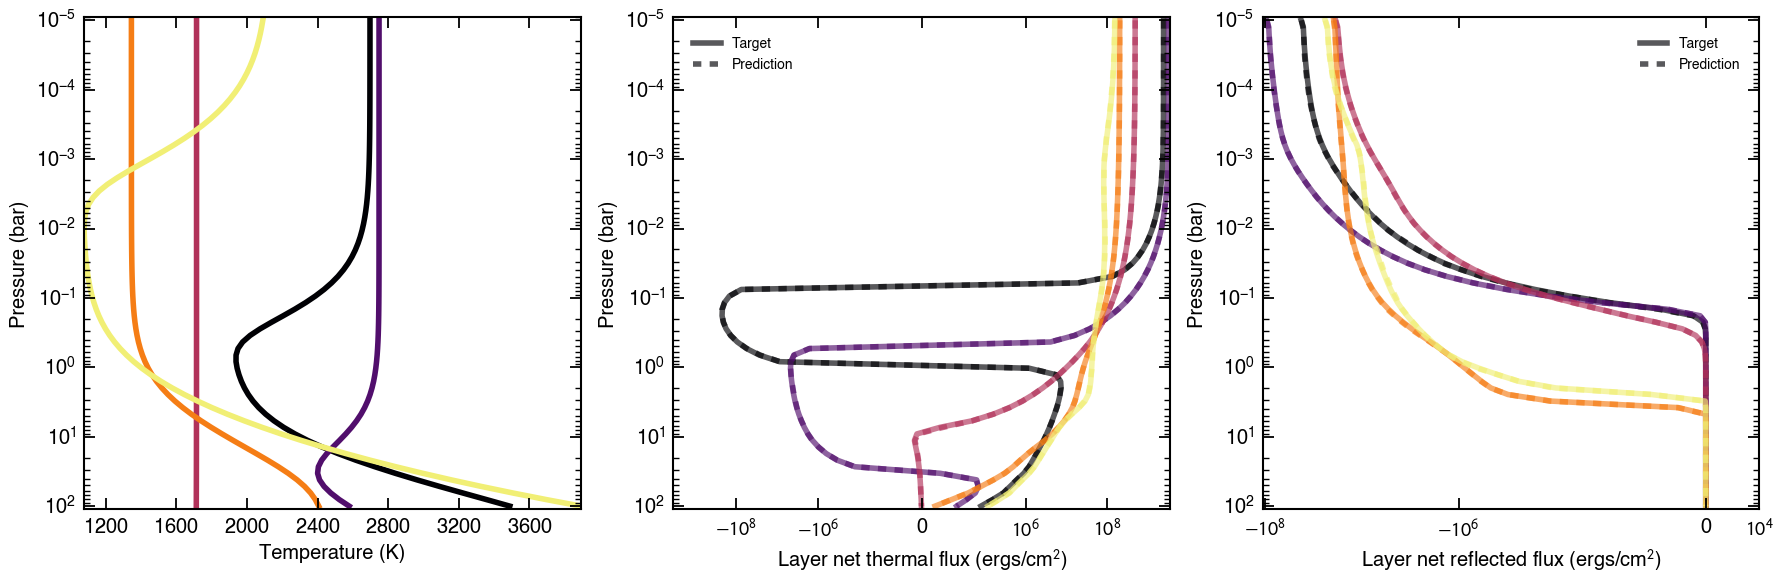

In [19]:
if MODEL_PRESENT:
    import h5py
    from matplotlib.ticker import FixedLocator, NullLocator

    OOPS_PROFILE_INDICES = [0, 2, 3, 4, 6]

    # Choose x ticks separately for each panel.
    # Use None to let Matplotlib choose automatically.
    TEMP_XTICKS = None
    THERMAL_XTICKS = [-1e10, -1e8, -1e6, 0.0, 1e6, 1e8, 1e10]

    # Last panel: mostly negative, but goes slightly positive.
    REFLECTED_XTICKS = [-1e10, -1e8, -1e6, 0.0, 1e4]
    REFLECTED_XLIM = (None, 1e4)

    def apply_xticks(ax, xticks=None):
        if xticks is not None:
            ax.xaxis.set_major_locator(FixedLocator(xticks))
            ax.xaxis.set_minor_locator(NullLocator())

    h5_path_main = PROJECT_ROOT / "data" / "raw" / h5_files[0]
    max_len = int(train_config["model_hyperparameters"]["max_sequence_length"])
    in_vars = train_config["data_specification"]["input_variables"]
    glob_vars = train_config["data_specification"]["global_variables"]
    tgt_vars = train_config["data_specification"]["target_variables"]
    pad_v = float(train_config["data_specification"]["padding_value"])

    thermal_idx = tgt_vars.index("net_thermal_flux")
    reflected_idx = tgt_vars.index("net_reflected_flux")

    program_oops = torch.export.load(str(STANDALONE_PT2))
    model_oops = program_oops.module().to("cpu")

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    (axes if isinstance(axes, np.ndarray) else np.array([axes])).ravel()  # no-op shim

    for _ax in plt.gcf().axes:
        _ax.grid(False, which="both")

    colors = plt.cm.inferno(np.linspace(0, 0.95, len(OOPS_PROFILE_INDICES)))
    _all_P, _all_th, _all_rf = [], [], []

    with h5py.File(h5_path_main, "r") as hf:
        for j, idx in enumerate(OOPS_PROFILE_INDICES):
            if idx >= hf[in_vars[0]].shape[0]:
                continue

            color = colors[j]

            seq = np.stack([hf[v][idx] for v in in_vars], axis=-1).astype(np.float32)
            seq_t = torch.from_numpy(seq).unsqueeze(0)

            if seq_t.shape[1] < max_len:
                pad_shape = (
                    seq_t.shape[0],
                    max_len - seq_t.shape[1],
                    seq_t.shape[2],
                )
                seq_t = torch.cat(
                    [seq_t, torch.full(pad_shape, pad_v)],
                    dim=1,
                )

            glb = None
            if glob_vars:
                glb_vals = np.array(
                    [hf[v][idx] for v in glob_vars],
                    dtype=np.float32,
                ).reshape(1, -1)
                glb = torch.from_numpy(glb_vals)

            with torch.inference_mode():
                pred = model_oops(
                    sequence_phys=seq_t.cpu(),
                    global_features_phys=glb.cpu() if glb is not None else None,
                )

            pred_np = pred.cpu().numpy()[0]
            L_real = hf[in_vars[0]][idx].shape[0]

            P = hf["pressure_bar"][idx]
            T = hf["temperature_k"][idx]
            targ_th = hf["net_thermal_flux"][idx]
            targ_rf = hf["net_reflected_flux"][idx]
            pred_th = pred_np[:L_real, thermal_idx]
            pred_rf = pred_np[:L_real, reflected_idx]

            v = (P > 0) & np.isfinite(P) & np.isfinite(T)

            axes[0].plot(
                T[v],
                P[v],
                color=color,
                linewidth=4.0,
                label=f"Profile {idx}",
            )
            axes[1].plot(
                targ_th[v],
                P[v],
                "-",
                color=color,
                linewidth=4.0,
                alpha=0.65,
                label="Target" if j == 0 else None,
            )
            axes[1].plot(
                pred_th[v],
                P[v],
                "--",
                color=color,
                linewidth=4.0,
                alpha=0.65,
                label="Prediction" if j == 0 else None,
            )
            axes[2].plot(
                targ_rf[v],
                P[v],
                "-",
                color=color,
                linewidth=4.0,
                alpha=0.65,
                label="Target" if j == 0 else None,
            )
            axes[2].plot(
                pred_rf[v],
                P[v],
                "--",
                color=color,
                linewidth=4.0,
                alpha=0.65,
                label="Prediction" if j == 0 else None,
            )

            _all_P.append(P[v])
            _all_th.append(np.concatenate([targ_th[v], pred_th[v]]))
            _all_rf.append(np.concatenate([targ_rf[v], pred_rf[v]]))

    _P_all = np.concatenate(_all_P) if _all_P else np.array([])
    _th_all = np.concatenate(_all_th) if _all_th else np.array([])
    _rf_all = np.concatenate(_all_rf) if _all_rf else np.array([])

    # Panel 1: temperature x-axis, log inverted pressure y-axis.
    axes[0].set_xlabel("Temperature (K)")
    axes[0].set_ylabel("Pressure (bar)")
    pad_log_lim(axes[0], _P_all, axis="y", invert=True)
    apply_xticks(axes[0], TEMP_XTICKS)

    # Panel 2: thermal flux x-axis, log inverted pressure y-axis.
    axes[1].set_xlabel("Layer net thermal flux (ergs/cm$^2$)")
    axes[1].set_ylabel("Pressure (bar)")
    pad_symlog_lim(axes[1], _th_all, axis="x", linthresh=1e4, linscale=0.5)
    pad_log_lim(axes[1], _P_all, axis="y", invert=True)
    apply_xticks(axes[1], THERMAL_XTICKS)
    axes[1].legend(fontsize=10, loc="best")

    # Panel 3: reflected flux x-axis, log inverted pressure y-axis.
    axes[2].set_xlabel("Layer net reflected flux (ergs/cm$^2$)")
    axes[2].set_ylabel("Pressure (bar)")
    pad_symlog_lim(axes[2], _rf_all, axis="x", linthresh=1e4, linscale=0.5)
    axes[2].set_xlim(REFLECTED_XLIM)
    pad_log_lim(axes[2], _P_all, axis="y", invert=True)
    apply_xticks(axes[2], REFLECTED_XTICKS)
    axes[2].legend(fontsize=10, loc="best")

    out = FIGS_DIR / "atmospheric_profiles_3panel_with_preds.png"

    cap_ticks_all(8)

    # cap_ticks_all can overwrite locators/limits, so force your chosen x ticks/limits again.
    apply_xticks(axes[0], TEMP_XTICKS)
    apply_xticks(axes[1], THERMAL_XTICKS)
    apply_xticks(axes[2], REFLECTED_XTICKS)
    axes[2].set_xlim(REFLECTED_XLIM)

    plt.tight_layout()
    plt.savefig(out, dpi=150, bbox_inches="tight")
    print(f"Saved: {out}")
    plt.show()

else:
    print("Skipped atmospheric_profiles_3panel_with_preds.png — needs trained model.")

Saved: /Users/imalsky/Desktop/Emulators/RT-Project/Problemulator_extra_runs/testing/figs_final/atmospheric_profiles_3panel_with_preds_lstm.png


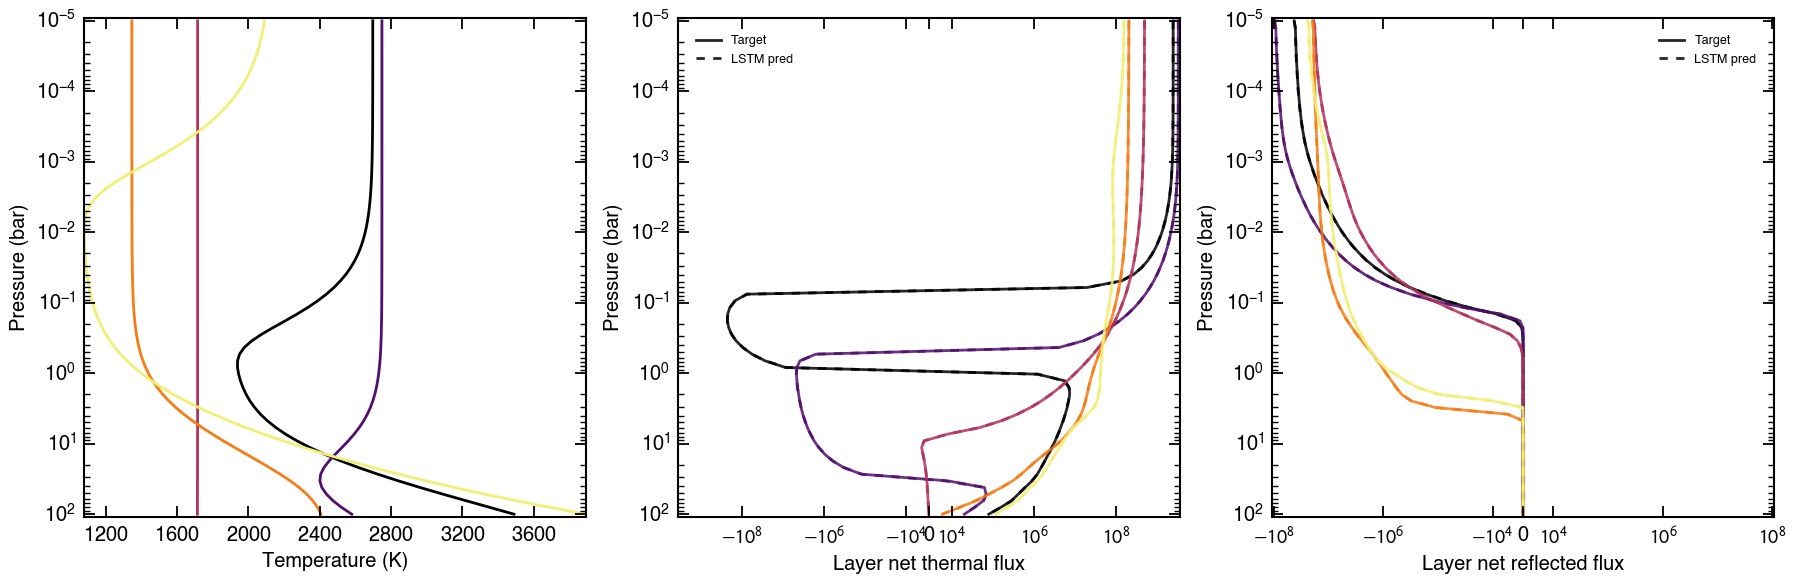

In [20]:
# LSTM atmospheric profiles 3-panel with predictions + 2-row comparison.
if LSTM_MODEL_PRESENT:
    import h5py as _h5py
    PROF_IDX = [0, 2, 3, 4, 6]
    h5_path_main = PROJECT_ROOT / "data" / "raw" / h5_files[0]
    in_v = lstm_train_config["data_specification"]["input_variables"]
    gl_v = lstm_train_config["data_specification"]["global_variables"]
    tg_v = lstm_train_config["data_specification"]["target_variables"]
    pad_v = float(lstm_train_config["data_specification"]["padding_value"])
    max_len = int(lstm_train_config["model_hyperparameters"]["max_sequence_length"])
    th_i = tg_v.index("net_thermal_flux"); rf_i = tg_v.index("net_reflected_flux")
    model_l_inf = load_inference_module(LSTM_MODEL_DIR)

    def _plot_3panel(model_inf, axes_row, arch_label):
        colors_loc = plt.cm.inferno(np.linspace(0, 0.95, len(PROF_IDX)))
        _all_P, _all_th, _all_rf = [], [], []
        with _h5py.File(h5_path_main, "r") as hf:
            for j, idx in enumerate(PROF_IDX):
                if idx >= hf[in_v[0]].shape[0]:
                    continue
                color = colors_loc[j]
                seq = np.stack([hf[v][idx] for v in in_v], axis=-1).astype(np.float32)
                seq_t = torch.from_numpy(seq).unsqueeze(0)
                if seq_t.shape[1] < max_len:
                    pad_shape = (seq_t.shape[0], max_len - seq_t.shape[1], seq_t.shape[2])
                    seq_t = torch.cat([seq_t, torch.full(pad_shape, pad_v)], dim=1)
                glb = None
                if gl_v:
                    glb_vals = np.array([hf[v][idx] for v in gl_v], dtype=np.float32).reshape(1, -1)
                    glb = torch.from_numpy(glb_vals)
                pred = predict_physical(model_inf, seq_t, glb)
                L_real = hf[in_v[0]][idx].shape[0]
                P = hf["pressure_bar"][idx]; T = hf["temperature_k"][idx]
                targ_th = hf["net_thermal_flux"][idx]; targ_rf = hf["net_reflected_flux"][idx]
                pred_th = pred.cpu().numpy()[0, :L_real, th_i]
                pred_rf = pred.cpu().numpy()[0, :L_real, rf_i]
                v = (P > 0) & np.isfinite(P) & np.isfinite(T)
                axes_row[0].plot(T[v], P[v], color=color, linewidth=2.0, label=f"Profile {idx}")
                axes_row[1].plot(targ_th[v], P[v], "-", color=color, linewidth=2.0, alpha=0.85, label="Target" if j == 0 else None)
                axes_row[1].plot(pred_th[v], P[v], "--", color=color, linewidth=2.0, alpha=0.85, label=f"{arch_label} pred" if j == 0 else None)
                axes_row[2].plot(targ_rf[v], P[v], "-", color=color, linewidth=2.0, alpha=0.85, label="Target" if j == 0 else None)
                axes_row[2].plot(pred_rf[v], P[v], "--", color=color, linewidth=2.0, alpha=0.85, label=f"{arch_label} pred" if j == 0 else None)
                _all_P.append(P[v])
                _all_th.append(np.concatenate([targ_th[v], pred_th[v]]))
                _all_rf.append(np.concatenate([targ_rf[v], pred_rf[v]]))
        _P_all = np.concatenate(_all_P) if _all_P else np.array([])
        _th_all = np.concatenate(_all_th) if _all_th else np.array([])
        _rf_all = np.concatenate(_all_rf) if _all_rf else np.array([])
        axes_row[0].set_xlabel("Temperature (K)"); axes_row[0].set_ylabel("Pressure (bar)")
        pad_log_lim(axes_row[0], _P_all, axis="y", invert=True)

        axes_row[1].set_xlabel("Layer net thermal flux"); axes_row[1].set_ylabel("Pressure (bar)")
        pad_symlog_lim(axes_row[1], _th_all, axis="x", linthresh=1e4, linscale=0.5)
        pad_log_lim(axes_row[1], _P_all, axis="y", invert=True)
        axes_row[1].legend(fontsize=9, loc="best")

        axes_row[2].set_xlabel("Layer net reflected flux"); axes_row[2].set_ylabel("Pressure (bar)")
        pad_symlog_lim(axes_row[2], _rf_all, axis="x", linthresh=1e4, linscale=0.5)
        pad_log_lim(axes_row[2], _P_all, axis="y", invert=True)
        axes_row[2].legend(fontsize=9, loc="best")

    fig, axes_lstm = plt.subplots(1, 3, figsize=(18, 6))
    _plot_3panel(model_l_inf, axes_lstm, MODELS["lstm"]["label"])
    plt.tight_layout()
    out_lstm = FIGS_DIR / "atmospheric_profiles_3panel_with_preds_lstm.png"
    cap_ticks_all(8); plt.savefig(out_lstm, dpi=150, bbox_inches="tight")
    print(f"Saved: {out_lstm}"); plt.show()
else:
    print("Skipped LSTM 3-panel with preds - LSTM .pt2 missing.")

## Flux predictions per sample (2×2 grid)


Saved: /Users/imalsky/Desktop/Emulators/RT-Project/Problemulator_extra_runs/testing/figs_final/flux_predictions_samples_lstm.png


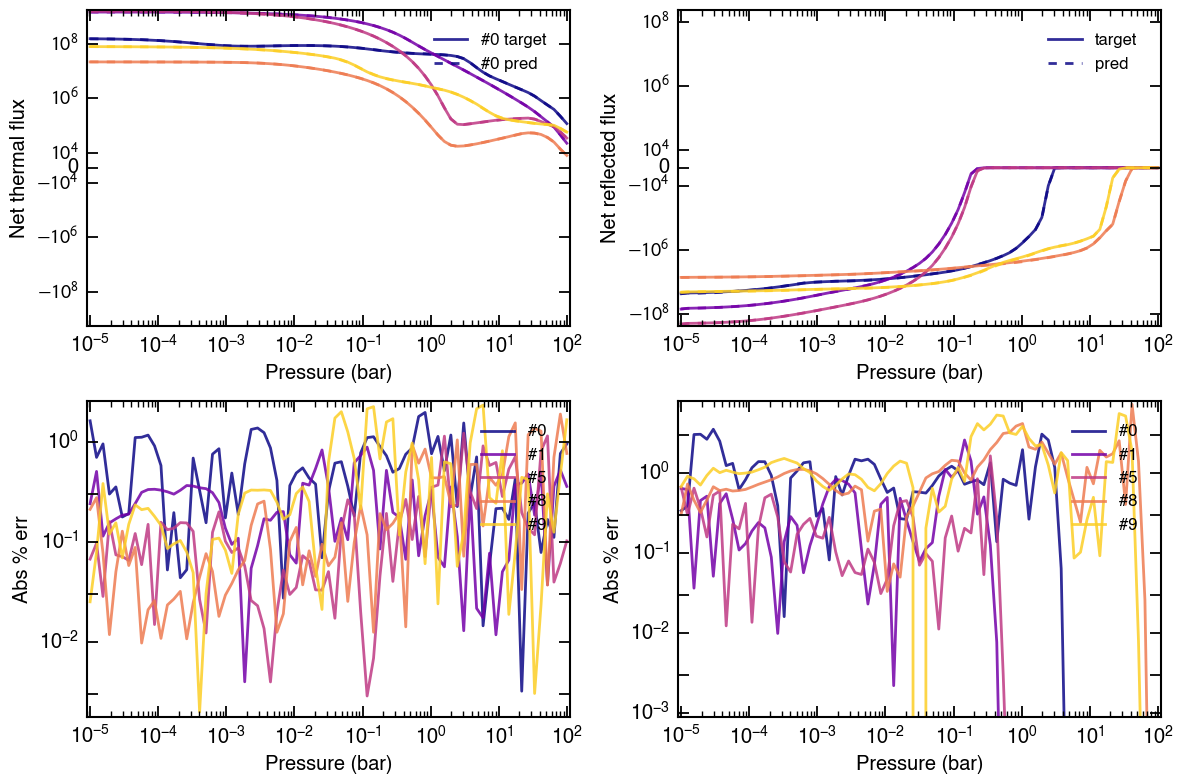

In [21]:
# LSTM flux predictions per sample (2x2 grid) + comparison.
if LSTM_MODEL_PRESENT:
    SAMPLE_IDX_L = [0, 1, 5, 8, 9]
    model_l_inf = load_inference_module(LSTM_MODEL_DIR)
    iv_l = lstm_train_config["data_specification"]["input_variables"]
    tv_l = lstm_train_config["data_specification"]["target_variables"]
    p_i = iv_l.index("pressure_bar"); th_i = tv_l.index("net_thermal_flux"); rf_i = tv_l.index("net_reflected_flux")
    pad_val = float(lstm_train_config["data_specification"]["padding_value"])
    pad_eps = float(lstm_train_config["normalization"]["padding_comparison_epsilon"])

    def _gather_sample_preds(model_inf, config, samp_idx):
        loader = DataLoader(create_dataset(PROC_TEST, config, [samp_idx]),
                            batch_size=1, shuffle=False,
                            collate_fn=create_collate_fn(pad_val, pad_eps))
        bi, bm, bt, btm = next(iter(loader))
        sp, gp, tp, tm = denormalize_batch(config, norm_meta, bi, bm, bt, btm)
        pp = predict_physical(model_inf, sp, gp)
        return sp, pp, tp, tm

    def _plot_2x2(model_inf, config, axes_grid, color_seq):
        _pr_all, _th_all, _rf_all, _the_all, _rfe_all = [], [], [], [], []
        for k, samp_idx in enumerate(SAMPLE_IDX_L):
            sp, pp, tp, tm = _gather_sample_preds(model_inf, config, samp_idx)
            valid_k = (~tm[0]).cpu().numpy()
            pr = sp[0, :, p_i].cpu().numpy()[valid_k]
            th_t = tp[0, :, th_i].cpu().numpy()[valid_k]; th_p = pp[0, :, th_i].cpu().numpy()[valid_k]
            rf_t = tp[0, :, rf_i].cpu().numpy()[valid_k]; rf_p = pp[0, :, rf_i].cpu().numpy()[valid_k]
            th_err = 100 * np.abs(th_p - th_t) / np.maximum(np.abs(th_t), 1.0)
            rf_err = 100 * np.abs(rf_p - rf_t) / np.maximum(np.abs(rf_t), 1.0)
            c = color_seq[k]
            axes_grid[0, 0].plot(pr, th_t, "-", color=c, linewidth=2.0, alpha=0.85, label=f"#{samp_idx} target" if k == 0 else None)
            axes_grid[0, 0].plot(pr, th_p, "--", color=c, linewidth=2.0, alpha=0.85, label=f"#{samp_idx} pred" if k == 0 else None)
            axes_grid[1, 0].plot(pr, th_err, color=c, linewidth=2.0, alpha=0.85, label=f"#{samp_idx}")
            axes_grid[0, 1].plot(pr, rf_t, "-", color=c, linewidth=2.0, alpha=0.85, label="target" if k == 0 else None)
            axes_grid[0, 1].plot(pr, rf_p, "--", color=c, linewidth=2.0, alpha=0.85, label="pred" if k == 0 else None)
            axes_grid[1, 1].plot(pr, rf_err, color=c, linewidth=2.0, alpha=0.85, label=f"#{samp_idx}")
            _pr_all.append(pr)
            _th_all.append(np.concatenate([th_t, th_p]))
            _rf_all.append(np.concatenate([rf_t, rf_p]))
            _the_all.append(th_err); _rfe_all.append(rf_err)
        _pr_cat = np.concatenate(_pr_all) if _pr_all else np.array([])
        _th_cat = np.concatenate(_th_all) if _th_all else np.array([])
        _rf_cat = np.concatenate(_rf_all) if _rf_all else np.array([])
        _the_cat = np.concatenate(_the_all) if _the_all else np.array([])
        _rfe_cat = np.concatenate(_rfe_all) if _rfe_all else np.array([])
        for ax in axes_grid.flat:
            pad_log_lim(ax, _pr_cat, axis="x")
        pad_symlog_lim(axes_grid[0, 0], _th_cat, axis="y", linthresh=1e4, linscale=0.5)
        axes_grid[0, 0].set_xlabel("Pressure (bar)"); axes_grid[0, 0].set_ylabel("Net thermal flux"); axes_grid[0, 0].legend()
        pad_log_lim(axes_grid[1, 0], np.maximum(_the_cat, 1e-3), axis="y")
        axes_grid[1, 0].set_xlabel("Pressure (bar)"); axes_grid[1, 0].set_ylabel("Abs % err"); axes_grid[1, 0].legend()
        pad_symlog_lim(axes_grid[0, 1], _rf_cat, axis="y", linthresh=1e4, linscale=0.5)
        axes_grid[0, 1].set_xlabel("Pressure (bar)"); axes_grid[0, 1].set_ylabel("Net reflected flux"); axes_grid[0, 1].legend()
        pad_log_lim(axes_grid[1, 1], np.maximum(_rfe_cat, 1e-3), axis="y")
        axes_grid[1, 1].set_xlabel("Pressure (bar)"); axes_grid[1, 1].set_ylabel("Abs % err"); axes_grid[1, 1].legend()

    fig, axes_lstm = plt.subplots(2, 2, figsize=(12, 8))
    _plot_2x2(model_l_inf, lstm_train_config, axes_lstm, plt.cm.plasma(np.linspace(0, 0.9, len(SAMPLE_IDX_L))))
    plt.tight_layout()
    out_lstm = FIGS_DIR / "flux_predictions_samples_lstm.png"
    cap_ticks_all(8); plt.savefig(out_lstm, dpi=150, bbox_inches="tight")
    print(f"Saved: {out_lstm}"); plt.show()
else:
    print("Skipped LSTM flux_predictions_samples - LSTM .pt2 missing.")

## Pressure-binned signed % error (pastel bands)


Saved: /Users/imalsky/Desktop/Emulators/RT-Project/Problemulator_extra_runs/testing/figs_final/pressure_error_pastel_bands.png


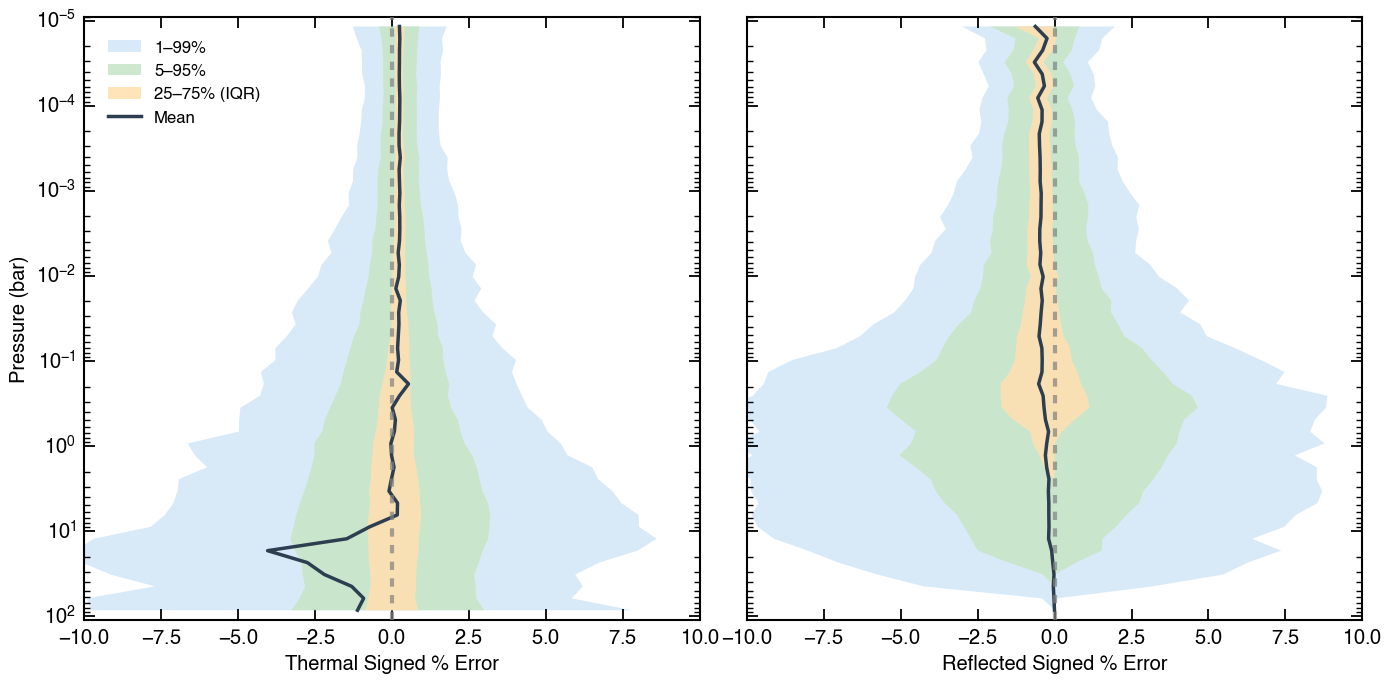

In [22]:
if MODEL_PRESENT and "ERR_RAW" in dir():
    BAND_1 = "#D4E8F7"
    BAND_5 = "#C8E6C9"
    BAND_25 = "#FFE0B2"
    MEAN_LINE = "#2C3E50"

    # Fixed signed percent-error range for both panels.
    ERROR_XLIM = 10.0

    flux_names = list(ERR_RAW.keys())

    fig, axes = plt.subplots(1, len(flux_names), figsize=(14, 7), sharey=True, sharex=True)
    (axes if isinstance(axes, np.ndarray) else np.array([axes])).ravel()  # no-op shim

    for _ax in plt.gcf().axes:
        _ax.grid(False, which="both")

    if len(flux_names) == 1:
        axes = [axes]

    for ax, name in zip(axes, flux_names):
        prs = ERR_RAW[name]["pressures"]
        diffs = ERR_RAW[name]["diffs"]
        truths = ERR_RAW[name]["truths"]

        denom = np.maximum(np.abs(truths), 1.0)
        signed_pct = 100.0 * diffs / denom

        sel = prs > 0
        prs, signed_pct = prs[sel], signed_pct[sel]

        if prs.size == 0:
            ax.text(
                0.5,
                0.5,
                "No data",
                ha="center",
                va="center",
                transform=ax.transAxes,
            )
            continue

        n_bins = 50
        bins = np.logspace(np.log10(prs.min()), np.log10(prs.max()), n_bins + 1)
        idxs = np.digitize(prs, bins, right=False) - 1
        keep = (idxs >= 0) & (idxs < n_bins)
        prs, signed_pct, idxs = prs[keep], signed_pct[keep], idxs[keep]

        centers, means, q25, q75, q05, q95, q01, q99 = [], [], [], [], [], [], [], []

        for i in range(n_bins):
            bsel = idxs == i
            if bsel.sum() < 3:
                continue

            vals = signed_pct[bsel]

            centers.append(float(np.sqrt(bins[i] * bins[i + 1])))
            means.append(float(np.mean(vals)))
            q25.append(float(np.percentile(vals, 25)))
            q75.append(float(np.percentile(vals, 75)))
            q05.append(float(np.percentile(vals, 5)))
            q95.append(float(np.percentile(vals, 95)))
            q01.append(float(np.percentile(vals, 1)))
            q99.append(float(np.percentile(vals, 99)))

        centers = np.array(centers)

        ax.fill_betweenx(
            centers,
            q01,
            q99,
            color=BAND_1,
            alpha=0.9,
            edgecolor="none",
            label="1–99%",
            zorder=2,
        )
        ax.fill_betweenx(
            centers,
            q05,
            q95,
            color=BAND_5,
            alpha=0.9,
            edgecolor="none",
            label="5–95%",
            zorder=3,
        )
        ax.fill_betweenx(
            centers,
            q25,
            q75,
            color=BAND_25,
            alpha=0.9,
            edgecolor="none",
            label="25–75% (IQR)",
            zorder=4,
        )
        ax.plot(
            means,
            centers,
            color=MEAN_LINE,
            linewidth=2.5,
            label="Mean",
            zorder=5,
        )

        ax.axvline(
            0.0,
            color="gray",
            linestyle="dashed",
            linewidth=3.0,
            alpha=0.7,
            zorder=10,
        )

        label = "Thermal" if name == "net_thermal_flux" else "Reflected"
        ax.set_xlabel(f"{label} Signed % Error")
        ax.set_xlim(-ERROR_XLIM, ERROR_XLIM)

        if ax is axes[0]:
            ax.legend(loc="upper left", framealpha=0.95, fancybox=True, shadow=True)

    axes[0].set_ylabel("Pressure (bar)")

    # All-binned pressure range across both channels for the y-axis limit.
    _all_pres = np.concatenate([ERR_RAW[_n]["pressures"] for _n in flux_names])

    for ax in axes:
        pad_log_lim(ax, _all_pres, axis="y", invert=True)
        ax.set_xlim(-ERROR_XLIM, ERROR_XLIM)

    plt.tight_layout()
    out = FIGS_DIR / "pressure_error_pastel_bands.png"

    cap_ticks_all(8)

    # cap_ticks_all can overwrite limits, so force the x-limits again.
    for ax in axes:
        ax.set_xlim(-ERROR_XLIM, ERROR_XLIM)

    plt.savefig(out, dpi=150, bbox_inches="tight", facecolor="white")
    print(f"Saved: {out}")
    plt.show()

else:
    print("Skipped pressure_error_pastel_bands.png — needs ERR_RAW.")

Saved: /Users/imalsky/Desktop/Emulators/RT-Project/Problemulator_extra_runs/testing/figs_final/pressure_error_pastel_bands_lstm.png


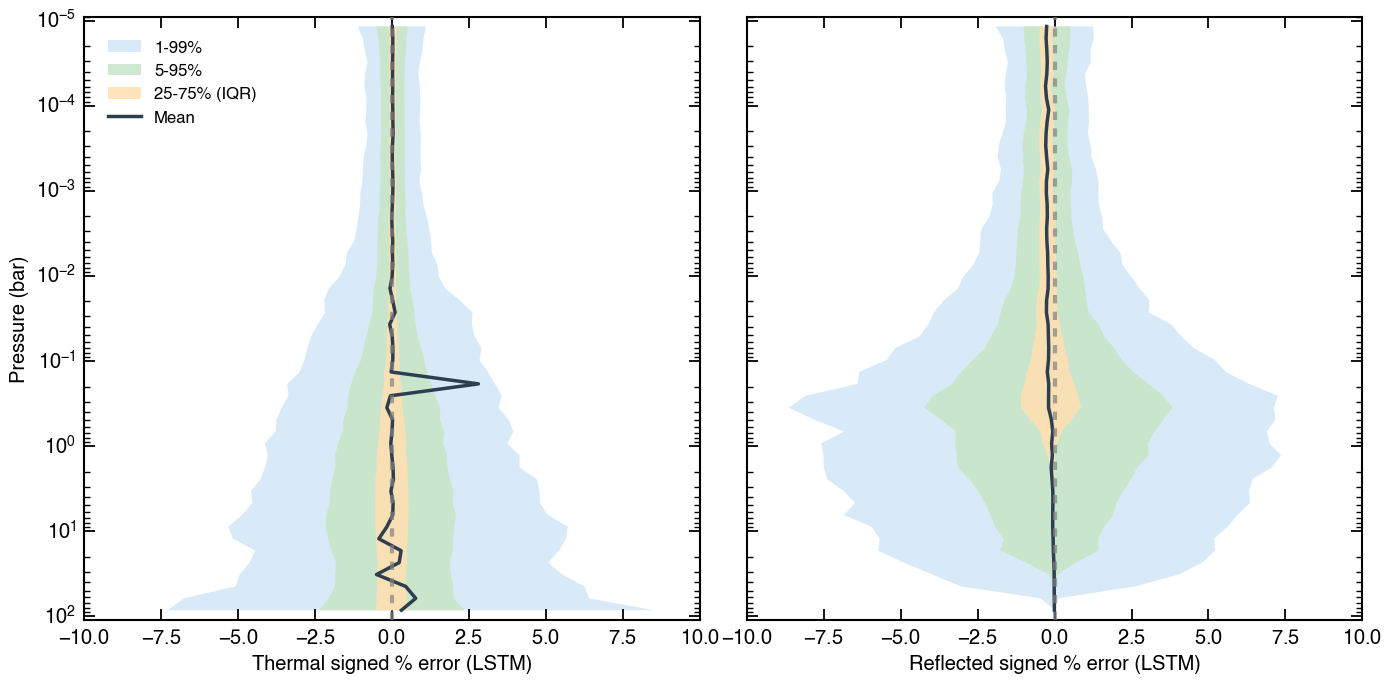

Saved: /Users/imalsky/Desktop/Emulators/RT-Project/Problemulator_extra_runs/testing/figs_final/pressure_error_pastel_bands_comparison.png


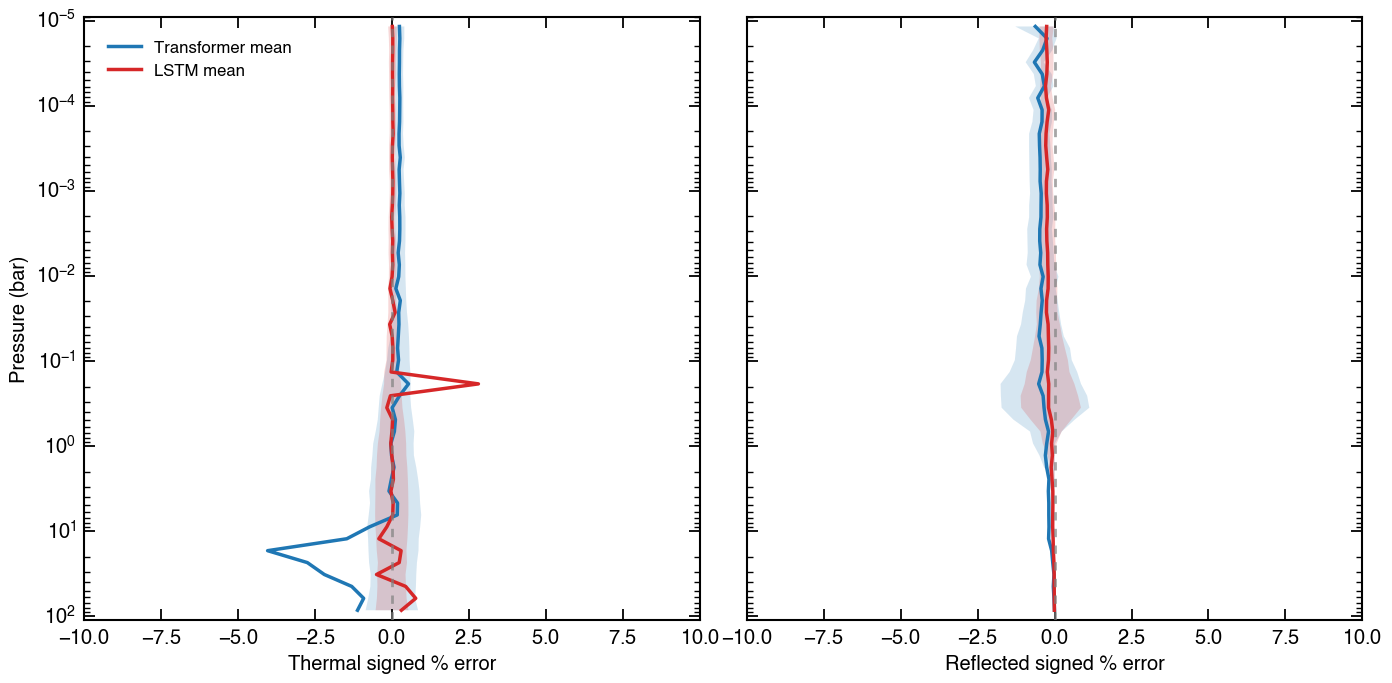

In [23]:
# LSTM pressure-binned signed % error + comparison overlay.
if LSTM_MODEL_PRESENT and ERR_RAW_LSTM:
    BAND_1 = "#D4E8F7"
    BAND_5 = "#C8E6C9"
    BAND_25 = "#FFE0B2"
    MEAN_LINE = "#2C3E50"

    # Fixed signed percent-error range for all panels.
    ERROR_XLIM = 10.0

    flux_names = list(ERR_RAW_LSTM.keys())

    def _pressure_bins(prs, signed_pct, n_bins=50):
        sel = prs > 0
        prs, signed_pct = prs[sel], signed_pct[sel]

        if prs.size == 0:
            return [], [], [], [], [], [], [], [], []

        bins = np.logspace(np.log10(prs.min()), np.log10(prs.max()), n_bins + 1)
        idxs = np.digitize(prs, bins, right=False) - 1
        keep = (idxs >= 0) & (idxs < n_bins)
        prs, signed_pct, idxs = prs[keep], signed_pct[keep], idxs[keep]

        centers, means, q25, q75, q05, q95, q01, q99 = [], [], [], [], [], [], [], []

        for i in range(n_bins):
            bsel = idxs == i
            if bsel.sum() < 3:
                continue

            vals = signed_pct[bsel]

            centers.append(float(np.sqrt(bins[i] * bins[i + 1])))
            means.append(float(np.mean(vals)))
            q25.append(float(np.percentile(vals, 25)))
            q75.append(float(np.percentile(vals, 75)))
            q05.append(float(np.percentile(vals, 5)))
            q95.append(float(np.percentile(vals, 95)))
            q01.append(float(np.percentile(vals, 1)))
            q99.append(float(np.percentile(vals, 99)))

        return centers, means, q25, q75, q05, q95, q01, q99, bins

    fig, axes = plt.subplots(1, len(flux_names), figsize=(14, 7), sharey=True, sharex=True)

    if len(flux_names) == 1:
        axes = [axes]

    for ax, name in zip(axes, flux_names):
        prs = ERR_RAW_LSTM[name]["pressures"]
        diffs = ERR_RAW_LSTM[name]["diffs"]
        truths = ERR_RAW_LSTM[name]["truths"]

        signed_pct = 100.0 * diffs / np.maximum(np.abs(truths), 1.0)

        centers, means, q25, q75, q05, q95, q01, q99, _ = _pressure_bins(prs, signed_pct)

        if not centers:
            ax.text(
                0.5,
                0.5,
                "No data",
                ha="center",
                va="center",
                transform=ax.transAxes,
            )
            continue

        centers = np.array(centers)

        ax.fill_betweenx(
            centers,
            q01,
            q99,
            color=BAND_1,
            alpha=0.9,
            edgecolor="none",
            label="1-99%",
            zorder=2,
        )
        ax.fill_betweenx(
            centers,
            q05,
            q95,
            color=BAND_5,
            alpha=0.9,
            edgecolor="none",
            label="5-95%",
            zorder=3,
        )
        ax.fill_betweenx(
            centers,
            q25,
            q75,
            color=BAND_25,
            alpha=0.9,
            edgecolor="none",
            label="25-75% (IQR)",
            zorder=4,
        )
        ax.plot(
            means,
            centers,
            color=MEAN_LINE,
            linewidth=2.5,
            label="Mean",
            zorder=5,
        )

        ax.axvline(
            0.0,
            color="gray",
            linestyle="dashed",
            linewidth=3.0,
            alpha=0.7,
            zorder=10,
        )

        lbl = "Thermal" if name == "net_thermal_flux" else "Reflected"
        ax.set_xlabel(f"{lbl} signed % error (LSTM)")
        ax.set_xlim(-ERROR_XLIM, ERROR_XLIM)

        if ax is axes[0]:
            ax.legend(loc="upper left", framealpha=0.95)

    axes[0].set_ylabel("Pressure (bar)")

    _all_pres_l = np.concatenate([ERR_RAW_LSTM[_n]["pressures"] for _n in flux_names])

    for ax in axes:
        pad_log_lim(ax, _all_pres_l, axis="y", invert=True)
        ax.set_xlim(-ERROR_XLIM, ERROR_XLIM)

    plt.tight_layout()

    out_lstm = FIGS_DIR / "pressure_error_pastel_bands_lstm.png"

    cap_ticks_all(8)

    # cap_ticks_all can overwrite limits, so force the x-limits again.
    for ax in axes:
        ax.set_xlim(-ERROR_XLIM, ERROR_XLIM)

    plt.savefig(out_lstm, dpi=150, bbox_inches="tight", facecolor="white")
    print(f"Saved: {out_lstm}")
    plt.show()

    # Comparison overlay: mean lines for both architectures on same panel per channel
    if MODEL_PRESENT and "ERR_RAW" in dir():
        fig, axes = plt.subplots(1, len(flux_names), figsize=(14, 7), sharey=True, sharex=True)

        if len(flux_names) == 1:
            axes = [axes]

        for ax, name in zip(axes, flux_names):
            for arch, ERR in [("transformer", ERR_RAW), ("lstm", ERR_RAW_LSTM)]:
                prs = ERR[name]["pressures"]
                diffs = ERR[name]["diffs"]
                truths = ERR[name]["truths"]

                signed_pct = 100.0 * diffs / np.maximum(np.abs(truths), 1.0)

                centers, means, q25, q75, _, _, _, _, _ = _pressure_bins(prs, signed_pct)

                if not centers:
                    continue

                centers = np.array(centers)
                c = MODELS[arch]["color"]

                ax.fill_betweenx(
                    centers,
                    q25,
                    q75,
                    color=c,
                    alpha=0.18,
                    edgecolor="none",
                    zorder=2,
                )
                ax.plot(
                    means,
                    centers,
                    color=c,
                    linewidth=2.5,
                    label=f"{MODELS[arch]['label']} mean",
                    zorder=5,
                )

            ax.axvline(
                0.0,
                color="gray",
                linestyle="dashed",
                linewidth=2.0,
                alpha=0.7,
                zorder=10,
            )

            lbl = "Thermal" if name == "net_thermal_flux" else "Reflected"
            ax.set_xlabel(f"{lbl} signed % error")
            ax.set_xlim(-ERROR_XLIM, ERROR_XLIM)

            if ax is axes[0]:
                ax.legend(loc="upper left", framealpha=0.95)

        axes[0].set_ylabel("Pressure (bar)")

        _all_pres_cmp = np.concatenate([
            np.concatenate([ERR_RAW[_n]["pressures"], ERR_RAW_LSTM[_n]["pressures"]])
            for _n in flux_names
        ])

        for ax in axes:
            pad_log_lim(ax, _all_pres_cmp, axis="y", invert=True)
            ax.set_xlim(-ERROR_XLIM, ERROR_XLIM)

        plt.tight_layout()

        out_cmp = FIGS_DIR / "pressure_error_pastel_bands_comparison.png"

        cap_ticks_all(8)

        # cap_ticks_all can overwrite limits, so force the x-limits again.
        for ax in axes:
            ax.set_xlim(-ERROR_XLIM, ERROR_XLIM)

        plt.savefig(out_cmp, dpi=150, bbox_inches="tight", facecolor="white")
        print(f"Saved: {out_cmp}")
        plt.show()

else:
    print("Skipped LSTM pressure_error_pastel_bands - LSTM ERR_RAW missing.")

## Eager-model inference throughput vs batch size


Saved: /Users/imalsky/Desktop/Emulators/RT-Project/Problemulator_extra_runs/testing/figs_final/benchmark_throughput.png


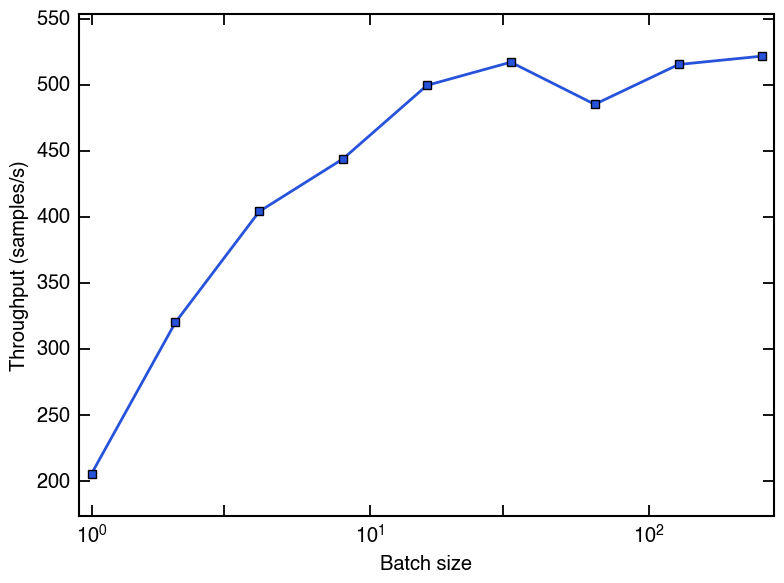

Wrote inference_benchmark_mps.json


In [24]:
if MODEL_PRESENT:
    from model import create_prediction_model
    BENCH_BATCH_SIZES = [1, 2, 4, 8, 16, 32, 64, 128, 256]
    WARMUP_CALLS = 10
    REPEATS_BENCH = 5
    CALLS_PER = 3

    torch.set_default_device("cpu")
    bench_model = create_prediction_model(config=train_config, device=torch.device("cpu"), compile_model=False).eval()
    ckpt = torch.load(MODEL_DIR / "best_model.pt", map_location="cpu", weights_only=False)
    state = ckpt["state_dict"]
    if any(k.startswith("_orig_mod.") for k in state):
        state = {k.replace("_orig_mod.", ""): v for k, v in state.items()}
    bench_model.load_state_dict(state, strict=True)
    bench_model = bench_model.to("cpu", dtype=torch.float32).eval()

    seq_len_b = int(train_config["model_hyperparameters"]["max_sequence_length"])
    in_dim_b = len(train_config["data_specification"]["input_variables"])
    g_dim_b = len(train_config["data_specification"]["global_variables"])

    mean_ms, std_ms = [], []
    for B in BENCH_BATCH_SIZES:
        seq = torch.randn(B, seq_len_b, in_dim_b, dtype=torch.float32)
        msk = torch.zeros(B, seq_len_b, dtype=torch.bool)
        glob = torch.randn(B, g_dim_b, dtype=torch.float32) if g_dim_b > 0 else None
        with torch.inference_mode():
            for _ in range(WARMUP_CALLS):
                bench_model(seq, glob, msk)
            ts = []
            for _ in range(REPEATS_BENCH):
                t0 = time.perf_counter_ns()
                for _ in range(CALLS_PER):
                    bench_model(seq, glob, msk)
                dt = (time.perf_counter_ns() - t0) / 1e6
                ts.append(dt / CALLS_PER)
        a = np.asarray(ts)
        mean_ms.append(float(a.mean())); std_ms.append(float(a.std(ddof=1) if a.size > 1 else 0.0))

    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    (ax if isinstance(ax, np.ndarray) else np.array([ax])).ravel()  # no-op shim
    for _ax in (plt.gcf().axes):
        _ax.grid(False, which="both")
    tput = [B / (m / 1000.0) for B, m in zip(BENCH_BATCH_SIZES, mean_ms)]
    ax.plot(BENCH_BATCH_SIZES, tput, marker="s", markersize=6, linewidth=2)
    # Batch axis: log base 2 (powers-of-two batch sizes).
    ax.set_xscale("log", base=2)
    ax.set_xlim(min(BENCH_BATCH_SIZES) * 0.9, max(BENCH_BATCH_SIZES) * 1.1)
    # Throughput often spans more than a decade across batches; auto-detect and
    # use log-y with multiplicative padding when so, else linear with margin.
    _tput_arr = np.asarray(tput, dtype=float)
    _tput_pos = _tput_arr[_tput_arr > 0]
    if _tput_pos.size and (_tput_pos.max() / _tput_pos.min()) >= 10.0:
        pad_log_lim(ax, _tput_pos, axis="y")
    ax.set_xlabel("Batch size")
    ax.set_ylabel("Throughput (samples/s)")
    plt.tight_layout()
    out = FIGS_DIR / "benchmark_throughput.png"
    cap_ticks_all(8)
    plt.savefig(out, dpi=150, bbox_inches="tight")
    print(f"Saved: {out}")
    plt.show()

    THROUGHPUT_T_B256 = tput[BENCH_BATCH_SIZES.index(256)] if 256 in BENCH_BATCH_SIZES else None
    bench_data = {
        "device": str(DEVICE_RUN),
        "batch_sizes": BENCH_BATCH_SIZES,
        "mean_ms": mean_ms,
        "std_ms": std_ms,
        "throughput_samples_per_s": tput,
    }
    bench_json = MODEL_DIR / f"inference_benchmark_{DEVICE_RUN.type}.json"
    with bench_json.open("w") as f:
        json.dump(bench_data, f, indent=2)
    print(f"Wrote {bench_json.name}")
else:
    THROUGHPUT_T_B256 = None
    print("Skipped benchmark_throughput.png — needs trained model.")


Saved: /Users/imalsky/Desktop/Emulators/RT-Project/Problemulator_extra_runs/testing/figs_final/benchmark_throughput_lstm.png


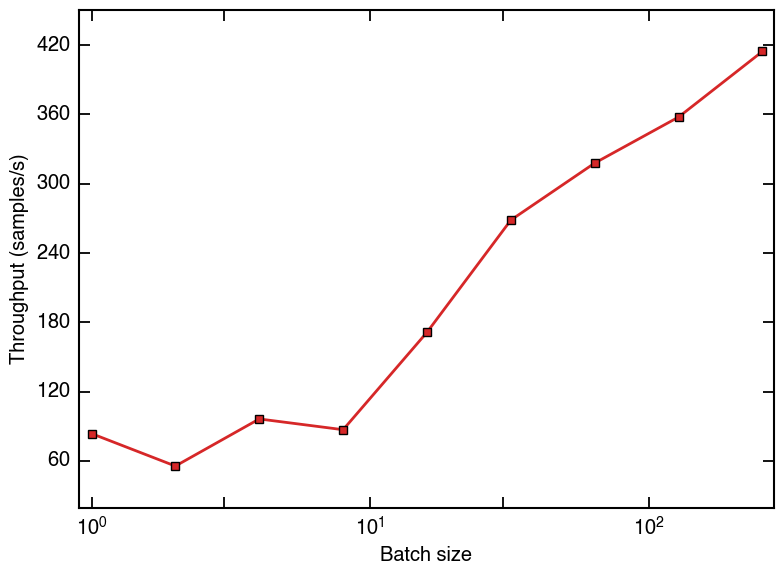

Saved: /Users/imalsky/Desktop/Emulators/RT-Project/Problemulator_extra_runs/testing/figs_final/benchmark_throughput_comparison.png


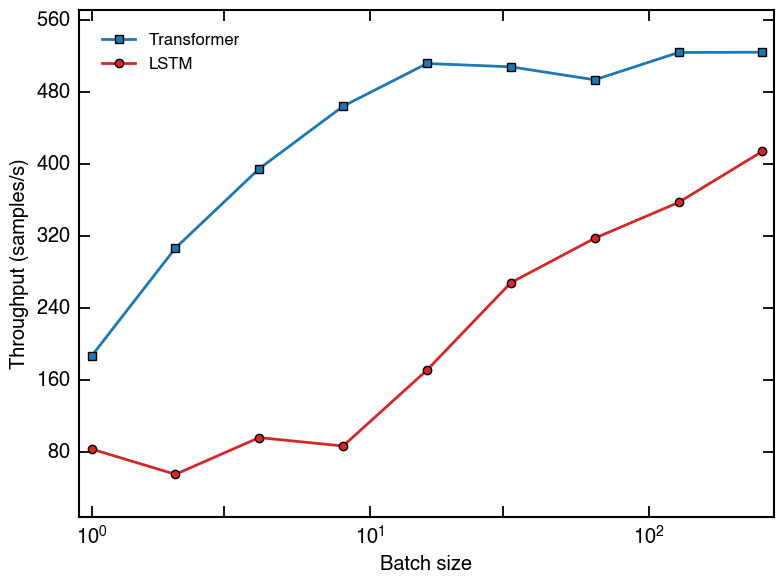

In [25]:
# LSTM eager-model inference throughput + transformer-vs-LSTM overlay.
if LSTM_MODEL_PRESENT:
    from model import create_prediction_model
    BENCH_BS = [1, 2, 4, 8, 16, 32, 64, 128, 256]
    WARMUP_BENCH = 10
    REPEATS_BENCH_L = 5
    CALLS_PER_BENCH = 3

    def _benchmark(model_inf, config, seq_len, in_dim, glob_dim):
        means, stds = [], []
        for B in BENCH_BS:
            seq = torch.randn(B, seq_len, in_dim, dtype=torch.float32)
            msk = torch.zeros(B, seq_len, dtype=torch.bool)
            glob = torch.randn(B, glob_dim, dtype=torch.float32) if glob_dim > 0 else None
            with torch.inference_mode():
                for _ in range(WARMUP_BENCH):
                    model_inf(seq, glob, msk)
                ts = []
                for _ in range(REPEATS_BENCH_L):
                    t0 = time.perf_counter_ns()
                    for _ in range(CALLS_PER_BENCH):
                        model_inf(seq, glob, msk)
                    ts.append((time.perf_counter_ns() - t0) / 1e6 / CALLS_PER_BENCH)
            a = np.asarray(ts)
            means.append(float(a.mean())); stds.append(float(a.std(ddof=1) if a.size > 1 else 0.0))
        return means, stds

    torch.set_default_device("cpu")
    bench_lstm = create_prediction_model(config=lstm_train_config, device=torch.device("cpu"), compile_model=False).eval()
    ckpt_lb = torch.load(LSTM_MODEL_DIR / "best_model.pt", map_location="cpu", weights_only=False)
    state_lb = ckpt_lb["state_dict"]
    if any(k.startswith("_orig_mod.") for k in state_lb):
        state_lb = {k.replace("_orig_mod.", ""): v for k, v in state_lb.items()}
    bench_lstm.load_state_dict(state_lb, strict=True)
    bench_lstm = bench_lstm.to("cpu", dtype=torch.float32).eval()

    seq_len_l = int(lstm_train_config["model_hyperparameters"]["max_sequence_length"])
    in_dim_l = len(lstm_train_config["data_specification"]["input_variables"])
    g_dim_l = len(lstm_train_config["data_specification"]["global_variables"])
    mean_ms_l, std_ms_l = _benchmark(bench_lstm, lstm_train_config, seq_len_l, in_dim_l, g_dim_l)
    tput_l = [B / (m / 1000.0) for B, m in zip(BENCH_BS, mean_ms_l)]

    bench_json_l = {
        "backend": "eager_cpu",
        "batch_sizes": BENCH_BS,
        "latency_ms_mean": mean_ms_l,
        "latency_ms_std": std_ms_l,
        "throughput_samples_per_s": tput_l,
    }
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(BENCH_BS, tput_l, marker="s", markersize=6, linewidth=2, color=MODELS["lstm"]["color"])
    ax.set_xscale("log", base=2); ax.set_xlim(min(BENCH_BS) * 0.9, max(BENCH_BS) * 1.1)
    _tput_arr = np.asarray(tput_l, dtype=float); _tput_pos = _tput_arr[_tput_arr > 0]
    if _tput_pos.size and (_tput_pos.max() / _tput_pos.min()) >= 10.0:
        pad_log_lim(ax, _tput_pos, axis="y")
    ax.set_xlabel("Batch size"); ax.set_ylabel("Throughput (samples/s)")
    plt.tight_layout()
    out_lstm = FIGS_DIR / "benchmark_throughput_lstm.png"
    cap_ticks_all(8); plt.savefig(out_lstm, dpi=150, bbox_inches="tight")
    print(f"Saved: {out_lstm}"); plt.show()

    if MODEL_PRESENT:
        # Re-bench the transformer to get mean_ms/tput on the same axes; the original
        # cell already exists, so just reuse its computation by re-loading. Note:
        # `mean_ms` and `tput` from the transformer cell are not exported to globals
        # consistently across kernels, so we recompute here.
        bench_t = create_prediction_model(config=train_config, device=torch.device("cpu"), compile_model=False).eval()
        ckpt_tb = torch.load(MODEL_DIR / "best_model.pt", map_location="cpu", weights_only=False)
        state_tb = ckpt_tb["state_dict"]
        if any(k.startswith("_orig_mod.") for k in state_tb):
            state_tb = {k.replace("_orig_mod.", ""): v for k, v in state_tb.items()}
        bench_t.load_state_dict(state_tb, strict=True)
        bench_t = bench_t.to("cpu", dtype=torch.float32).eval()
        seq_len_t = int(train_config["model_hyperparameters"]["max_sequence_length"])
        in_dim_t = len(train_config["data_specification"]["input_variables"])
        g_dim_t = len(train_config["data_specification"]["global_variables"])
        mean_ms_t, std_ms_t = _benchmark(bench_t, train_config, seq_len_t, in_dim_t, g_dim_t)
        tput_t = [B / (m / 1000.0) for B, m in zip(BENCH_BS, mean_ms_t)]
        bench_json_t = {
            "backend": "eager_cpu",
            "batch_sizes": BENCH_BS,
            "latency_ms_mean": mean_ms_t,
            "latency_ms_std": std_ms_t,
            "throughput_samples_per_s": tput_t,
        }
        fig, ax = plt.subplots(figsize=(8, 6))
        ax.plot(BENCH_BS, tput_t, marker="s", markersize=6, linewidth=2, color=MODELS["transformer"]["color"], label=MODELS["transformer"]["label"])
        ax.plot(BENCH_BS, tput_l, marker="o", markersize=6, linewidth=2, color=MODELS["lstm"]["color"], label=MODELS["lstm"]["label"])
        ax.set_xscale("log", base=2); ax.set_xlim(min(BENCH_BS) * 0.9, max(BENCH_BS) * 1.1)
        _both = np.asarray(tput_t + tput_l, dtype=float); _both_pos = _both[_both > 0]
        if _both_pos.size and (_both_pos.max() / _both_pos.min()) >= 10.0:
            pad_log_lim(ax, _both_pos, axis="y")
        ax.set_xlabel("Batch size"); ax.set_ylabel("Throughput (samples/s)")
        ax.legend(loc="best")
        plt.tight_layout()
        out_cmp = FIGS_DIR / "benchmark_throughput_comparison.png"
        cap_ticks_all(8); plt.savefig(out_cmp, dpi=150, bbox_inches="tight")
        print(f"Saved: {out_cmp}"); plt.show()
        # Stash for the numbers_for_response cell
        THROUGHPUT_T_B256 = float(tput_t[BENCH_BS.index(256)]) if 256 in BENCH_BS else float(tput_t[-1])
        THROUGHPUT_L_B256 = float(tput_l[BENCH_BS.index(256)]) if 256 in BENCH_BS else float(tput_l[-1])
    else:
        THROUGHPUT_T_B256 = None
        THROUGHPUT_L_B256 = float(tput_l[BENCH_BS.index(256)]) if 256 in BENCH_BS else float(tput_l[-1])
else:
    print("Skipped LSTM benchmark - LSTM_MODEL_DIR not populated.")
    THROUGHPUT_T_B256 = None
    THROUGHPUT_L_B256 = None

## Roth-dataset profiles + errors


In [26]:
# Write numbers_for_response.json with both architectures + tuning summary.
def _nullable_float(x):
    # NaN reads as "untested" in this artifact; emit null instead of non-standard JSON NaN.
    return None if (x is None or (isinstance(x, float) and math.isnan(x))) else float(x)

numbers = {}
if MODEL_PRESENT:
    numbers["transformer"] = {
        "params": int(num_parameters_t),
        "test_loss": _nullable_float(test_loss_t),
        "best_epoch": int(best_epoch),
        "val_at_best": float(val_at_best),
        "train_hours_total": float(train_hours_total),
        "epochs_completed": int(epochs_completed),
    }
    if "THROUGHPUT_T_B256" in dir() and THROUGHPUT_T_B256 is not None:
        numbers["transformer"]["throughput_b256_samples_per_s"] = float(THROUGHPUT_T_B256)
if LSTM_MODEL_PRESENT:
    numbers["lstm"] = {
        "params": int(num_parameters_l),
        "test_loss": _nullable_float(test_loss_l),
        "best_epoch": int(best_epoch_l),
        "val_at_best": float(val_at_best_l),
        "train_hours_total": float(train_hours_total_l),
        "epochs_completed": int(epochs_completed_l),
    }
    if "THROUGHPUT_L_B256" in dir() and THROUGHPUT_L_B256 is not None:
        numbers["lstm"]["throughput_b256_samples_per_s"] = float(THROUGHPUT_L_B256)

if TUNE_PRESENT:
    numbers["tuning"] = {
        "study_name": STUDY_NAME,
        "n_trials_total": n_total,
        "n_trials_complete": n_complete,
        "n_trials_pruned": n_pruned,
        "n_trials_running": n_running,
        "n_trials_failed": n_failed,
        "sweep_in_progress": bool(SWEEP_IN_PROGRESS),
        "best_transformer_trial": int(best_t_trial),
        "best_transformer_val_loss": float(best_t_val),
        "best_transformer_params": int(best_t_params),
    }
    if best_l is not None:
        numbers["tuning"].update({
            "best_lstm_trial": int(best_l_trial),
            "best_lstm_val_loss": float(best_l_val),
            "best_lstm_params": int(best_l_params),
        })

nfr_path = OUTPUTS_DIR / "numbers_for_response.json"
with nfr_path.open("w") as f:
    json.dump(numbers, f, indent=2)
print(f"Wrote {nfr_path.name}")
print(json.dumps(numbers, indent=2))


Wrote numbers_for_response.json
{
  "transformer": {
    "params": 9734146,
    "test_loss": 9.947802936949302e-06,
    "best_epoch": 133,
    "val_at_best": 9.748308e-06,
    "train_hours_total": 9.396805555555556,
    "epochs_completed": 163,
    "throughput_b256_samples_per_s": 524.726273843878
  },
  "lstm": {
    "params": 9730050,
    "test_loss": 6.598377240152331e-06,
    "best_epoch": 297,
    "val_at_best": 6.542752e-06,
    "train_hours_total": 15.192833333333333,
    "epochs_completed": 300,
    "throughput_b256_samples_per_s": 414.6060697761771
  }
}


In [27]:
sweep_files = [
    FIGS_DIR / "reviewer_fig_pt.png",
]
if TUNE_PRESENT:
    sweep_files.append(FIGS_DIR / "reviewer_fig_pareto.png")
trained_only_files = [
    FIGS_DIR / "reviewer_fig_training_curves.png",
    FIGS_DIR / "reviewer_fig_profiles.png",
    FIGS_DIR / "reviewer_fig_residuals.png",
    FIGS_DIR / "atmospheric_profiles_3panel.png",
    FIGS_DIR / "atmospheric_profiles_3panel_with_preds.png",
    FIGS_DIR / "pressure_error_pastel_bands.png",
    FIGS_DIR / "benchmark_throughput.png",
    STANDALONE_PT2,
]
lstm_only_files = [
    FIGS_DIR / "reviewer_fig_profiles_lstm.png",
    FIGS_DIR / "reviewer_fig_residuals_lstm.png",
    FIGS_DIR / "atmospheric_profiles_3panel_with_preds_lstm.png",
    FIGS_DIR / "flux_predictions_samples_lstm.png",
    FIGS_DIR / "pressure_error_pastel_bands_lstm.png",
    FIGS_DIR / "benchmark_throughput_lstm.png",
]
comparison_files = [
    FIGS_DIR / "reviewer_fig_profiles_comparison.png",
    FIGS_DIR / "reviewer_fig_residuals_comparison.png",
    FIGS_DIR / "pressure_error_pastel_bands_comparison.png",
    FIGS_DIR / "benchmark_throughput_comparison.png",
]
required_files = sweep_files + (trained_only_files if MODEL_PRESENT else [])
if LSTM_MODEL_PRESENT:
    required_files = required_files + lstm_only_files
if MODEL_PRESENT and LSTM_MODEL_PRESENT:
    required_files = required_files + comparison_files
missing = [str(f) for f in required_files if not f.is_file()]
assert not missing, f"Missing artifacts: {missing}"

if TUNE_PRESENT:
    _l_pin = f", L={best_l_trial}" if best_l is not None else ""
    print(f"Best-trial pins (informational): T={best_t_trial}{_l_pin} "
          f"(sweep_in_progress={SWEEP_IN_PROGRESS}; pins re-enabled only after sweep finishes).")
else:
    print("No tuning sweep available -- skipping best-trial summary.")
if MODEL_PRESENT and TUNE_PRESENT:
    print("READY FOR RESPONSE (sweep + trained model)")
elif MODEL_PRESENT:
    print("READY FOR RESPONSE (trained model, no sweep)")
elif TUNE_PRESENT:
    print("READY FOR RESPONSE (sweep-only)")
else:
    print("READY FOR RESPONSE (no sweep, no trained model)")


No tuning sweep available -- skipping best-trial summary.
READY FOR RESPONSE (trained model, no sweep)
